In [1]:
# Explainable machine learning for household electricity demand forecasting.
#
# Dataset  : UCI Individual Household Electric Power Consumption
#            (December 2006 to November 2010, one-minute resolution)
# Target   : Global_active_power (kW)
# Pipeline : XGBoost, LightGBM, CatBoost and Random Forest base learners
#            combined by a constrained convex blend. The Holt-Winters
#            decomposition is retained as an analysis layer only.


In [2]:
# Package installation

import subprocess, sys

_PACKAGES = [
    'pandas>=1.5', 'numpy>=1.23', 'matplotlib>=3.6',
    'seaborn>=0.12', 'scikit-learn>=1.3', 'statsmodels>=0.14',
    'shap>=0.42', 'lime>=0.2', 'scipy>=1.10',
    'xgboost>=1.7', 'lightgbm>=4.0', 'catboost>=1.2', 'joblib>=1.2',
    'arch>=5.3',  # circular block bootstrap for autocorrelated residuals
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q'] + _PACKAGES
)
print('Package installation complete.')


Package installation complete.


In [3]:
# Imports and global configuration

from __future__ import annotations
import gc, warnings, json, time
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, wilcoxon

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import shap
from lime.lime_tabular import LimeTabularExplainer
import joblib


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directory
OUTPUT_DIR = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot style
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi':      110,
    'figure.figsize':  (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size':       10,
})
PALETTE = {
    'primary':   '#1f4e8c',
    'secondary': '#c0392b',
    'accent':    '#27ae60',
    'neutral':   '#7f8c8d',
}

# Figure conventions
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  12,
    'axes.labelsize':  11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'savefig.dpi':     400,
    'pdf.fonttype':    42, 
    'ps.fonttype':     42,
})

def savefig_pub(stem, fig=None, **kwargs):
    """Save a figure as a 400-dpi raster and a vector copy."""
    fig = fig if fig is not None else plt.gcf()
    kwargs.setdefault('bbox_inches', 'tight')
    fig.savefig(OUTPUT_DIR / f'{stem}.png', dpi=300, **kwargs)
    fig.savefig(OUTPUT_DIR / f'{stem}.pdf', **kwargs)

# Descriptive feature labels.


_RAW_VAR_LABELS = {
    'Global_active_power':   'Active power (kW)',
    'Global_reactive_power': 'Reactive power (kVAr)',
    'Voltage':               'Voltage (V)',
    'Global_intensity':      'Current intensity (A)',
    'Sub_metering_1':        'Kitchen sub-meter (Wh)',
    'Sub_metering_2':        'Laundry sub-meter (Wh)',
    'Sub_metering_3':        'Water-heater sub-meter (Wh)',
}

def _dur_label(m):
    """Readable duration for a horizon of m minutes."""
    m = int(m)
    if m % 1440 == 0:
        d = m // 1440
        return '1 day' if d == 1 else f'{d} days'
    if m % 60 == 0:
        h = m // 60
        return '1 hour' if h == 1 else f'{h} hours'
    return '1 minute' if m == 1 else f'{m} minutes'

def pub_label(feat):
    """Descriptive label for an engineered-feature name."""
    import re as _re
    f = str(feat)
    _fixed = {
        'diff_lag1_lag2':        'Load change (1 minute)',
        'diff_lag1_lag60':       'Load change (1 hour)',
        'gap_vs_yesterday':      'Change from previous day',
        'gap_vs_last_week':      'Change from previous week',
        'gap_vs_daily_mean':     'Deviation from daily mean',
        'gap_vs_weekly_mean':    'Deviation from weekly mean',
        'interaction_hour_lag1': 'Recent load by hour of day',
        'hour_sin':   'Hour of day (sine)',
        'hour_cos':   'Hour of day (cosine)',
        'day_sin':    'Day of week (sine)',
        'day_cos':    'Day of week (cosine)',
        'month_sin':  'Month of year (sine)',
        'month_cos':  'Month of year (cosine)',
        'mon_sin':    'Month of year (sine)',
        'mon_cos':    'Month of year (cosine)',
        'is_weekend': 'Weekend indicator',
        'hw_trend':        'Holt-Winters trend',
        'hw_seasonal':     'Holt-Winters seasonal term',
        'hw_residual':     'Holt-Winters residual',
        'hw_log_forecast': 'Holt-Winters forecast',
    }
    if f in _fixed:
        return _fixed[f]
    if f in _RAW_VAR_LABELS:
        return _RAW_VAR_LABELS[f]
    if f.endswith('_was_missing'):
        base = f[:-len('_was_missing')]
        base_lbl = _RAW_VAR_LABELS.get(base, base.replace('_', ' '))
        return f'Imputed reading ({base_lbl.split(" (")[0].lower()})'
    m = _re.search(r'_lag_(\d+)$', f)
    if m:
        return f'Load {_dur_label(int(m.group(1)))} earlier'
    m = _re.search(r'_roll_(mean|std|min|max)_(\d+)$', f)
    if m:
        stat = {'mean': 'Mean load', 'std': 'Standard deviation',
                'min': 'Minimum load', 'max': 'Maximum load'}[m.group(1)]
        return f'{stat} ({_dur_label(int(m.group(2)))})'
    m = _re.search(r'_ewm_(\d+)$', f)
    if m:
        return f'Smoothed load ({_dur_label(int(m.group(1)))})'
    m = _re.search(r'^f(?:ourier_)?([dw])_(sin|cos)_(\d+)$', f)
    if m:
        scope = 'Daily' if m.group(1) == 'd' else 'Weekly'
        trig = 'sine' if m.group(2) == 'sin' else 'cosine'
        return f'{scope} harmonic {m.group(3)} ({trig})'
    m = _re.search(r'hw_res(?:idual)?_lag_?(\d+)$', f)
    if m:
        return f'Holt-Winters residual ({_dur_label(int(m.group(1)))} earlier)'
    return f.replace('_', ' ')

print(f"Environment configured. Random seed: {RANDOM_STATE}")


Environment configured. Random seed: 42


In [4]:
# Data acquisition


import urllib.request, zipfile

DATA_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
DATA_ZIP  = Path('household_power_consumption.zip')
DATA_FILE = Path('household_power_consumption.txt')

if not DATA_FILE.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_ZIP)
    with zipfile.ZipFile(DATA_ZIP, 'r') as z:
        z.extractall('.')
    print('Download complete.')
else:
    print('Dataset already present on disk.')


Dataset already present on disk.


In [5]:
# Parsing and initial data-quality assessment
# The character '?' denotes a missing reading. The Date and Time fields are
# combined into a regular one-minute DatetimeIndex.

df_raw = pd.read_csv(
    DATA_FILE, sep=';', na_values=['?'],
    low_memory=False, dtype=str
)
dt = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S', errors='coerce'
)
df_raw = df_raw.drop(columns=['Date', 'Time'])
df_raw.index = dt
df_raw = df_raw[~df_raw.index.isna()].sort_index()
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw = df_raw.asfreq('1min')  # inserting empty rows for any skipped minutes

NUMERIC_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in NUMERIC_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape          : {df_raw.shape}")
print(f"Date range     : {df_raw.index.min()} to {df_raw.index.max()}")
print(f"Missing values : {df_raw[NUMERIC_COLS].isna().sum().sum():,}")

summary = df_raw[NUMERIC_COLS].describe().T
summary['missing_pct'] = df_raw[NUMERIC_COLS].isna().mean() * 100
print("\n--- Descriptive statistics ---")
print(summary.round(4).to_string())


Shape          : (2075259, 7)
Date range     : 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Missing values : 181,853

--- Descriptive statistics ---
                           count      mean     std      min      25%      50%      75%      max  missing_pct
Global_active_power    2049280.0    1.0916  1.0573    0.076    0.308    0.602    1.528   11.122       1.2518
Global_reactive_power  2049280.0    0.1237  0.1127    0.000    0.048    0.100    0.194    1.390       1.2518
Voltage                2049280.0  240.8399  3.2400  223.200  238.990  241.010  242.890  254.150       1.2518
Global_intensity       2049280.0    4.6278  4.4444    0.200    1.400    2.600    6.400   48.400       1.2518
Sub_metering_1         2049280.0    1.1219  6.1530    0.000    0.000    0.000    0.000   88.000       1.2518
Sub_metering_2         2049280.0    1.2985  5.8220    0.000    0.000    0.000    1.000   80.000       1.2518
Sub_metering_3         2049280.0    6.4584  8.4372    0.000    0.000    1.000   17.000   3

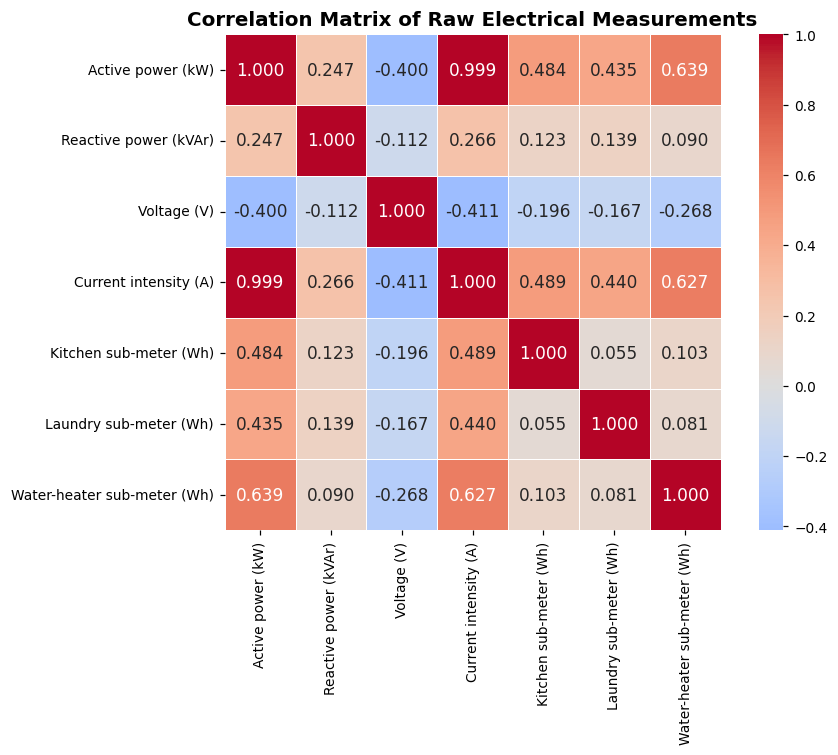

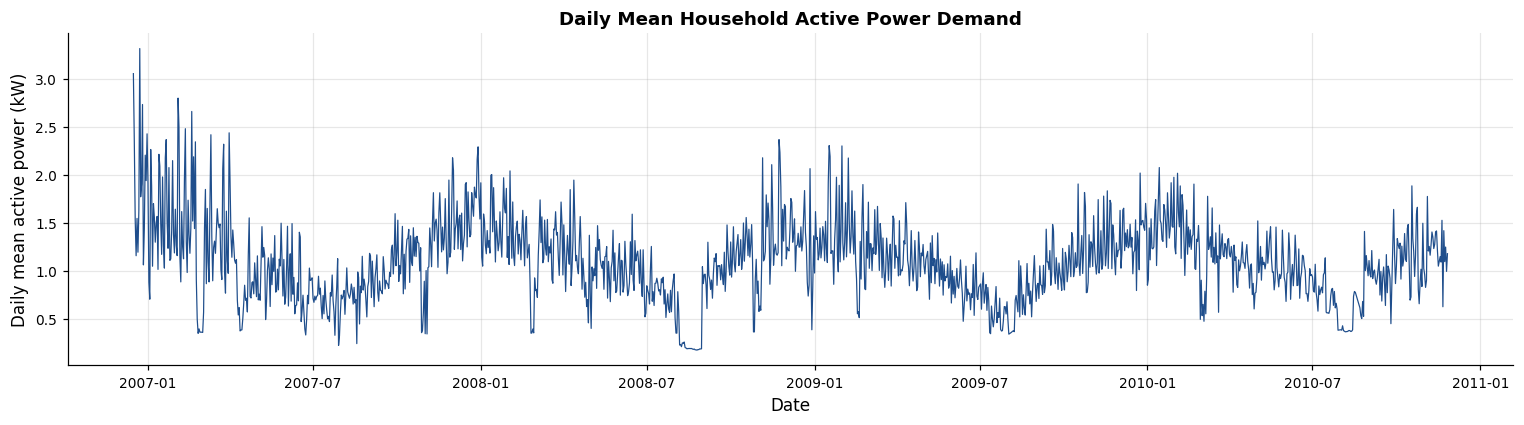


Running ADF on 34,168 hourly observations ...
ADF Statistic : -14.2374
p-value       : 1.5588e-26
  Critical (1%): -3.4305
  Critical (5%): -2.8616
  Critical (10%): -2.5668
Decision      : STATIONARY


1810

In [6]:
# Exploratory data analysis

# (a) Correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
corr  = df_raw[NUMERIC_COLS].corr()
# Descriptive measurement 
short = ['Active power (kW)', 'Reactive power (kVAr)', 'Voltage (V)',
         'Current intensity (A)', 'Kitchen sub-meter (Wh)',
         'Laundry sub-meter (Wh)', 'Water-heater sub-meter (Wh)']
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    xticklabels=short, yticklabels=short, ax=ax
)
ax.set_title('Correlation Matrix of Raw Electrical Measurements',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_pub('eda_correlation_heatmap')
plt.show()

# (b) Daily mean demand series
daily = df_raw['Global_active_power'].resample('D').mean().dropna()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color=PALETTE['primary'])
ax.set_title('Daily Mean Household Active Power Demand', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Daily mean active power (kW)'); ax.grid(alpha=0.3)
plt.tight_layout()
savefig_pub('eda_daily_power')
plt.show()

# (c) Augmented Dickey-Fuller stationarity test on hourly aggregates
series_hourly = df_raw['Global_active_power'].resample('h').mean().dropna()
print(f"\nRunning ADF on {len(series_hourly):,} hourly observations ...")
adf_stat, p_val, used_lag, nobs, crit_vals, _ = adfuller(series_hourly)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_val:.4e}")
for k, v in crit_vals.items():
    print(f"  Critical ({k}): {v:.4f}")
decision = 'STATIONARY' if p_val < 0.05 else 'NON-STATIONARY'
print(f"Decision      : {decision}")
del series_hourly; gc.collect()


In [7]:
# Preprocessing


df = df_raw[NUMERIC_COLS].copy()
for col in NUMERIC_COLS:
    df[f'{col}_was_missing'] = df[col].isna().astype('int8')
    df[col] = df[col].interpolate(method='time')
    df[col] = df[col].ffill().bfill()

for col in NUMERIC_COLS:
    df[col] = df[col].astype('float32')

print(f"Missing after imputation  : {df[NUMERIC_COLS].isna().sum().sum()}")
print(f"DataFrame memory          : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Missing after imputation  : 0
DataFrame memory          : 89.2 MB


In [8]:
# Feature engineering

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df.index.dayofweek >= 5).astype('int8')

CALENDAR_FEATURES = ['hour', 'day_of_week', 'month', 'is_weekend']

for (col, period) in [('hour', 24), ('day_of_week', 7), ('month', 12)]:
    suffix = col.split('_')[0] if '_' in col else col
    df[f'{suffix}_sin'] = np.sin(2*np.pi*df[col]/period).astype('float32')
    df[f'{suffix}_cos'] = np.cos(2*np.pi*df[col]/period).astype('float32')

CYCLICAL_FEATURES = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'mon_sin',  'mon_cos',
    'is_weekend',
]

# Fourier seasonal basis. The ablation study determines whether these
# fourteen additional columns are retained in the model feature set.
K_DAILY  = 4  # harmonics of the 1440-minute daily cycle
K_WEEKLY = 3  # harmonics of the 10080-minute weekly cycle

minute_of_day  = (df.index.hour * 60 + df.index.minute).astype('int32')
minute_of_week = (df.index.dayofweek * 1440 + minute_of_day).astype('int32')

for k in range(1, K_DAILY + 1):
    ang = 2.0 * np.pi * k * minute_of_day / 1440.0
    df[f'fourier_d_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_d_cos_{k}'] = np.cos(ang).astype('float32')

for k in range(1, K_WEEKLY + 1):
    ang = 2.0 * np.pi * k * minute_of_week / 10080.0
    df[f'fourier_w_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_w_cos_{k}'] = np.cos(ang).astype('float32')

FOURIER_FEATURES = (
    [f'fourier_d_sin_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_d_cos_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_w_sin_{k}' for k in range(1, K_WEEKLY + 1)]
    + [f'fourier_w_cos_{k}' for k in range(1, K_WEEKLY + 1)]
)

del minute_of_day, minute_of_week
gc.collect()

print(f"Cyclical features  : {CYCLICAL_FEATURES}")
print(f"Fourier features   : {len(FOURIER_FEATURES)} terms "
      f"(K_daily={K_DAILY}, K_weekly={K_WEEKLY})")
print(f"Total calendar+Fourier : {len(CYCLICAL_FEATURES) + len(FOURIER_FEATURES)}")


Cyclical features  : ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mon_sin', 'mon_cos', 'is_weekend']
Fourier features   : 14 terms (K_daily=4, K_weekly=3)
Total calendar+Fourier : 21


In [9]:
# Feature engineering: lags, rolling statistics, differences, exponentially
# weighted means and an interaction term.


TARGET          = 'Global_active_power'

LAG_STEPS       = [1, 2, 3, 5, 10, 15, 30, 60, 120, 240, 1440]

ROLLING_WINDOWS = [5, 15, 60, 180, 1440]

print(f"Generating {len(LAG_STEPS)} lag features ...")
for lag in LAG_STEPS:
    df[f'{TARGET}_lag_{lag}'] = df[TARGET].shift(lag).astype('float32')

print(f"Generating {len(ROLLING_WINDOWS)*4} rolling statistics "
      f"(mean, std. dev., minimum, maximum over {ROLLING_WINDOWS}) ...")
shifted = df[TARGET].shift(1)
for w in ROLLING_WINDOWS:
    r = shifted.rolling(window=w, min_periods=1)
    df[f'{TARGET}_roll_mean_{w}'] = r.mean().astype('float32')
    df[f'{TARGET}_roll_std_{w}']  = r.std().fillna(0).astype('float32')
    df[f'{TARGET}_roll_min_{w}']  = r.min().astype('float32')
    df[f'{TARGET}_roll_max_{w}']  = r.max().astype('float32')
del shifted

# Difference features
print("Generating difference features ...")
df['diff_lag1_lag2']  = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_2']).astype('float32')
df['diff_lag1_lag60'] = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_60']).astype('float32')

DIFF_FEATURES = ['diff_lag1_lag2', 'diff_lag1_lag60']

LAG_FEATURES     = [f'{TARGET}_lag_{l}' for l in LAG_STEPS]
ROLLING_FEATURES = (
    [f'{TARGET}_roll_{s}_{w}' for w in ROLLING_WINDOWS
     for s in ['mean', 'std', 'min', 'max']]
)


EWM_SPANS = [5, 30, 60, 1440]
print(f"Generating {len(EWM_SPANS)} exponentially weighted means "
      f"(spans={EWM_SPANS}) ...")
for span in EWM_SPANS:
    df[f'{TARGET}_ewm_{span}'] = (
        df[TARGET].shift(1)
        .ewm(span=span, min_periods=1, adjust=False)
        .mean()
        .astype('float32')
    )

EWM_FEATURES = [f'{TARGET}_ewm_{s}' for s in EWM_SPANS]


print("Generating hour-of-day interaction feature ...")
df['interaction_hour_lag1'] = (
    df['hour_sin'] * df[f'{TARGET}_lag_1']
).astype('float32')

INTERACTION_FEATURES = ['interaction_hour_lag1']

gc.collect()
print(f"\nAutoregressive feature counts:")
print(f"  Lags                       : {len(LAG_FEATURES)}")
print(f"  Rolling statistics         : {len(ROLLING_FEATURES)}")
print(f"  Differences                : {len(DIFF_FEATURES)}")
print(f"  Exponentially weighted     : {len(EWM_FEATURES)}")
print(f"  Interaction                : {len(INTERACTION_FEATURES)}")
print(f"  Total                      : {len(LAG_FEATURES)+len(ROLLING_FEATURES)+len(DIFF_FEATURES)+len(EWM_FEATURES)+len(INTERACTION_FEATURES)}")
print(f"  Longest lookback : {max(LAG_STEPS):,} min = {max(LAG_STEPS)/1440:.1f} days")
print(f"  Columns total    : {df.shape[1]}")
print(f"  Memory           : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Generating 11 lag features ...
Generating 20 rolling statistics (mean, std. dev., minimum, maximum over [5, 15, 60, 180, 1440]) ...
Generating difference features ...
Generating 4 exponentially weighted means (spans=[5, 30, 60, 1440]) ...
Generating hour-of-day interaction feature ...

Autoregressive feature counts:
  Lags                       : 11
  Rolling statistics         : 20
  Differences                : 2
  Exponentially weighted     : 4
  Interaction                : 1
  Total                      : 38
  Longest lookback : 1,440 min = 1.0 days
  Columns total    : 76
  Memory           : 738.8 MB


In [10]:
# Holt-Winters decomposition, used as an analysis layer rather than as the
# prediction base. A rolling refit with a 30-day step and an 18-month training
# window yields trend, seasonal and residual components as candidate features.


SEASONAL_PERIODS = 24
REFIT_DAYS       = 30
HISTORY_MONTHS   = 18

series_hourly     = df[TARGET].resample('h').mean().dropna()
series_hourly_log = np.log1p(series_hourly)
N_HOURLY          = len(series_hourly_log)
HW_TRAIN_END      = int(N_HOURLY * 0.70)

hw_train_series  = series_hourly_log.iloc[:HW_TRAIN_END]
hw_future_series = series_hourly_log.iloc[HW_TRAIN_END:]

print(f'HW fit on {len(hw_train_series):,} hourly obs '
      f'({hw_train_series.index.min().date()} to {hw_train_series.index.max().date()})')

hw_model_init = ExponentialSmoothing(
    hw_train_series, trend='add', seasonal='add',
    seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
).fit(optimized=True)

hw_fitted_train_h = pd.Series(hw_model_init.fittedvalues.values, index=hw_train_series.index)
level_h  = pd.Series(hw_model_init.level.values,  index=hw_train_series.index)
season_h = pd.Series(hw_model_init.season.values, index=hw_train_series.index)

# Rolling refits for val+test
refit_starts  = pd.date_range(start=hw_future_series.index[0],
                               end=hw_future_series.index[-1], freq=f'{REFIT_DAYS}D')
forecast_chunks = []
hw_model_train  = hw_model_init

for i, refit_date in enumerate(refit_starts):
    window_end   = refit_date - pd.Timedelta(hours=1)
    window_start = window_end - pd.DateOffset(months=HISTORY_MONTHS)
    train_win = series_hourly_log.loc[
        (series_hourly_log.index >= window_start) &
        (series_hourly_log.index <= window_end)
    ]
    if len(train_win) < SEASONAL_PERIODS * 4:
        train_win = series_hourly_log.loc[series_hourly_log.index <= window_end]
    hz_end = (refit_starts[i+1] - pd.Timedelta(hours=1)
              if i+1 < len(refit_starts) else hw_future_series.index[-1])
    fc_idx = hw_future_series.index[
        (hw_future_series.index >= refit_date) & (hw_future_series.index <= hz_end)
    ]
    if len(fc_idx) == 0:
        continue
    try:
        hw_m = ExponentialSmoothing(
            train_win, trend='add', seasonal='add',
            seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
        ).fit(optimized=True)
        fc = hw_m.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)
        hw_model_train = hw_m
    except Exception as e:
        fc = hw_model_init.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)

hw_log_forecast_h = (
    pd.concat([hw_fitted_train_h] + forecast_chunks)
    .pipe(lambda s: s[~s.index.duplicated(keep='first')])
    .sort_index()
    .reindex(series_hourly_log.index)
    .interpolate(method='time')
)
hw_resid_h = series_hourly_log - hw_log_forecast_h

# Forward-fill to minute level
df['hw_log_forecast'] = hw_log_forecast_h.reindex(df.index, method='ffill').bfill().astype('float32')
df['hw_residual']     = hw_resid_h.reindex(df.index,        method='ffill').bfill().astype('float32')
df['hw_trend']        = level_h.reindex(df.index,           method='ffill').bfill().astype('float32')
df['hw_seasonal']     = season_h.reindex(df.index,          method='ffill').bfill().astype('float32')

HW_FEATURES = ['hw_trend', 'hw_seasonal', 'hw_residual'] \


FITTED_HW_PARAMS = dict(
    model=hw_model_train, seasonal_periods=SEASONAL_PERIODS,
    refit_days=REFIT_DAYS, history_months=HISTORY_MONTHS,
)

_r2_hw = float(1 - np.nansum((series_hourly_log.values - hw_log_forecast_h.values)**2)
                  / np.nansum((series_hourly_log.values - series_hourly_log.mean())**2))
print(f'Rolling Holt-Winters refit complete: {len(refit_starts)} refits')
print(f'Hourly R² in log space   : {_r2_hw:.4f}   (analysis only)')
print(f'\nRole of the Holt-Winters components:')
print(f'  hw_log_forecast : excluded from the feature set')
print(f'  hw_trend        : ablation candidate')
print(f'  hw_seasonal     : ablation candidate')
print(f'  hw_residual     : ablation candidate')

del series_hourly, series_hourly_log, hw_future_series
gc.collect()


HW fit on 24,212 hourly obs (2006-12-16 to 2009-09-20)
Rolling Holt-Winters refit complete: 15 refits
Hourly R² in log space   : 0.2982   (analysis only)

Role of the Holt-Winters components:
  hw_log_forecast : excluded from the feature set
  hw_trend        : ablation candidate
  hw_seasonal     : ablation candidate
  hw_residual     : ablation candidate


0

In [11]:
# Feature engineering: memory-gap features


required = [
    f'{TARGET}_lag_1', f'{TARGET}_lag_1440',
    f'{TARGET}_roll_mean_1440',
]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing upstream features: {missing}"

l1    = df[f'{TARGET}_lag_1'].to_numpy(dtype='float32')
l1440 = df[f'{TARGET}_lag_1440'].to_numpy(dtype='float32')
rm1440 = df[f'{TARGET}_roll_mean_1440'].to_numpy(dtype='float32')

df['gap_vs_yesterday']  = (l1 - l1440 ).astype('float32')
df['gap_vs_daily_mean'] = (l1 - rm1440).astype('float32')

GAP_FEATURES = ['gap_vs_yesterday', 'gap_vs_daily_mean']

del l1, l1440, rm1440
gc.collect()

print(f"Memory-gap features : {GAP_FEATURES}")
print(f"Difference features : {['diff_lag1_lag2', 'diff_lag1_lag60']}")


Memory-gap features : ['gap_vs_yesterday', 'gap_vs_daily_mean']
Difference features : ['diff_lag1_lag2', 'diff_lag1_lag60']


In [12]:
# Chronological split and feature selection
# The sample is divided 70/15/15 in time order, so that no model is trained on
# observations later than those it is evaluated on.

df = df.dropna().copy()

ALWAYS_EXCLUDE = [
    TARGET,
    'Global_intensity',
    'Voltage',
    'Global_reactive_power',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'hw_log_forecast',  # analysis layer only
    # The integer calendar columns are superseded by their cyclical encodings.
    'hour', 'day_of_week', 'month',
]

FEATURE_COLS_FULL = [c for c in df.columns if c not in ALWAYS_EXCLUDE]

# Feature families
_fcset = set(FEATURE_COLS_FULL)
FAM_LAG      = [c for c in LAG_FEATURES     if c in _fcset]
FAM_ROLL     = [c for c in ROLLING_FEATURES if c in _fcset]
FAM_DIFF     = [c for c in DIFF_FEATURES    if c in _fcset]
FAM_CYCLICAL = [c for c in CYCLICAL_FEATURES if c in _fcset]
FAM_FOURIER  = [c for c in FOURIER_FEATURES  if c in _fcset]
FAM_GAP      = [c for c in GAP_FEATURES      if c in _fcset]
FAM_HW       = [c for c in HW_FEATURES       if c in _fcset]
FAM_EWM      = [c for c in EWM_FEATURES       if c in _fcset]
FAM_INTERACT = [c for c in INTERACTION_FEATURES if c in _fcset]


PRUNED_FAMILIES = FAM_HW
FEATURE_COLS = [c for c in FEATURE_COLS_FULL if c not in PRUNED_FAMILIES]

N         = len(df)
TRAIN_END = int(N * 0.70)
VAL_END   = int(N * 0.85)

train_df = df.iloc[:TRAIN_END]
val_df   = df.iloc[TRAIN_END:VAL_END]
test_df  = df.iloc[VAL_END:]

print(f'Training   : {len(train_df):>8,} rows  '
      f'({train_df.index.min().date()} to {train_df.index.max().date()})')
print(f'Validation : {len(val_df):>8,} rows  '
      f'({val_df.index.min().date()} to {val_df.index.max().date()})')
print(f'Test       : {len(test_df):>8,} rows  '
      f'({test_df.index.min().date()} to {test_df.index.max().date()})')
print(f'\nFeature families (full candidate set = {len(FEATURE_COLS_FULL)}):')
print(f'  Lags         : {len(FAM_LAG)}')
print(f'  Rolling      : {len(FAM_ROLL)}')
print(f'  Differences  : {len(FAM_DIFF)}')
print(f'  Cyclical     : {len(FAM_CYCLICAL)}')
print(f'  Fourier      : {len(FAM_FOURIER)}')
print(f'  Gap          : {len(FAM_GAP)}')
print(f'  Smoothed     : {len(FAM_EWM)}')
print(f'  Interaction  : {len(FAM_INTERACT)}')
print(f'  Holt-Winters : {len(FAM_HW)}  (removed on ablation evidence)')
print(f'\nModel feature set : {len(FEATURE_COLS)} columns')


Training   : 1,451,673 rows  (2006-12-17 to 2009-09-20)
Validation :  311,073 rows  (2009-09-20 to 2010-04-24)
Test       :  311,073 rows  (2010-04-24 to 2010-11-26)

Feature families (full candidate set = 71):
  Lags         : 11
  Rolling      : 20
  Differences  : 2
  Cyclical     : 5
  Fourier      : 14
  Gap          : 2
  Smoothed     : 4
  Interaction  : 1
  Holt-Winters : 3  (removed on ablation evidence)

Model feature set : 68 columns


In [13]:
# Standardisation

# Reduced model feature set
scaler      = StandardScaler()
X_train     = scaler.fit_transform(train_df[FEATURE_COLS]).astype('float32')
X_val       = scaler.transform(val_df[FEATURE_COLS]).astype('float32')
X_test      = scaler.transform(test_df[FEATURE_COLS]).astype('float32')

y_train     = train_df[TARGET].to_numpy(dtype='float32')
y_val       = val_df[TARGET].to_numpy(dtype='float32')
y_test      = test_df[TARGET].to_numpy(dtype='float32')

X_train_df  = pd.DataFrame(X_train, columns=FEATURE_COLS, index=train_df.index)
X_val_df    = pd.DataFrame(X_val,   columns=FEATURE_COLS, index=val_df.index)
X_test_df   = pd.DataFrame(X_test,  columns=FEATURE_COLS, index=test_df.index)

# Full candidate set, including the Holt-Winters columns
scaler_full     = StandardScaler()
X_train_full_df = pd.DataFrame(
    scaler_full.fit_transform(train_df[FEATURE_COLS_FULL]).astype('float32'),
    columns=FEATURE_COLS_FULL, index=train_df.index)
X_val_full_df   = pd.DataFrame(
    scaler_full.transform(val_df[FEATURE_COLS_FULL]).astype('float32'),
    columns=FEATURE_COLS_FULL, index=val_df.index)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}   (pruned model set)")
print(f"X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"X_test  : {X_test.shape}  dtype={X_test.dtype}")
print(f"Ablation set : {X_train_full_df.shape[1]} columns (Holt-Winters included)")
print(f"Arrays  : {(X_train.nbytes+X_val.nbytes+X_test.nbytes)/1e6:.0f} MB total")
gc.collect()


X_train : (1451673, 68)  dtype=float32   (pruned model set)
X_val   : (311073, 68)  dtype=float32
X_test  : (311073, 68)  dtype=float32
Ablation set : 71 columns (Holt-Winters included)
Arrays  : 564 MB total


0

In [14]:
# Evaluation utilities
# MAE, RMSE, R2, MAPE, sMAPE, MASE and directional accuracy

def mase(y_true, y_pred, y_train, seasonal_period=1440):
    """

    seasonal_period : steps per day of the evaluated series
                      (1440 = 1-min, 288 = 5-min, 144 = 10-min, 24 = hourly).
    """
    naive_errors = np.abs(y_train[seasonal_period:] - y_train[:-seasonal_period])
    mae_naive = naive_errors.mean()
    if mae_naive == 0:
        return np.nan
    return float(mean_absolute_error(y_true, y_pred) / mae_naive)

def directional_accuracy(y_true, y_pred):
    
    dy_true = np.diff(y_true)
    dy_pred = np.diff(y_pred)
    return float(np.mean(np.sign(dy_true) == np.sign(dy_pred)))

def block_bootstrap_ci(
    y_true, y_pred,
    metric_fn,
    n_boot=500,
    block_size=1440,
    alpha=0.05,
    rng_seed=42,
):
    
    try:
        from arch.bootstrap import CircularBlockBootstrap
        bs = CircularBlockBootstrap(block_size=block_size,
                                    x=np.column_stack([y_true, y_pred]),
                                    seed=rng_seed)
        def _metric(x_resamp):
            yt = x_resamp[:, 0].squeeze()
            yp = x_resamp[:, 1].squeeze()
            return metric_fn(yt, yp)
        ci = bs.conf_int(_metric, reps=n_boot, method='percentile',
                         size=1 - alpha)
        return float(ci[0][0]), float(ci[1][0])
    except Exception:
        # Fallback implementation, used when the `arch` package is unavailable.
        rng = np.random.default_rng(rng_seed)
        n = len(y_true)
        n_blocks = int(np.ceil(n / block_size))
        vals = []
        for _ in range(n_boot):
            starts = rng.integers(0, n, size=n_blocks)
            idx = np.concatenate([
                np.arange(s, s + block_size) % n for s in starts
            ])[:n]
            vals.append(metric_fn(y_true[idx], y_pred[idx]))
        lo = float(np.percentile(vals, 100 * alpha / 2))
        hi = float(np.percentile(vals, 100 * (1 - alpha / 2)))
        return lo, hi

def eval_metrics(
    y_true, y_pred,
    y_train_ref=None,
    seasonal_period=1440,  # daily seasonal naive at one-minute resolution
    compute_ci=False,
    ci_block_size=1440,
):
    y_true = np.asarray(y_true, dtype='float64')
    y_pred = np.asarray(y_pred, dtype='float64')

    mae  = float(mean_absolute_error(y_true, y_pred))
    mse  = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2   = float(r2_score(y_true, y_pred))

    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

    smape = float(np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100)

    result = dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2,
                  MAPE=mape, sMAPE=smape,
                  DA=directional_accuracy(y_true, y_pred))

    if y_train_ref is not None:
        result['MASE'] = mase(y_true, y_pred, y_train_ref, seasonal_period)

    if compute_ci:
        rmse_lo, rmse_hi = block_bootstrap_ci(
            y_true, y_pred,
            lambda a, b: float(np.sqrt(mean_squared_error(a, b))),
            block_size=ci_block_size,
        )
        r2_lo, r2_hi = block_bootstrap_ci(
            y_true, y_pred, r2_score, block_size=ci_block_size,
        )
        result['RMSE_CI'] = (rmse_lo, rmse_hi)
        result['R2_CI']   = (r2_lo,   r2_hi)

    return result

results = {}
print('Evaluation utilities defined.')


Evaluation utilities defined.


In [15]:
# Reference models
# Linear regression, LASSO, k-nearest neighbours, a random forest, a standalone
# gradient-boosted tree ensemble and an ARIMA model. The ARIMA model is fitted
# to hourly aggregates, so its errors are not directly comparable with those of
# the one-minute models and are reported separately.

tscv3 = TimeSeriesSplit(n_splits=3)

y_pred_persist = df[TARGET].shift(1).loc[test_df.index].to_numpy(dtype='float32')
results['Persistence'] = {
    'y_pred':  y_pred_persist,
    'metrics': eval_metrics(y_test, y_pred_persist, y_train_ref=y_train,
                            seasonal_period=1440),
}
print('Persistence (naive):', {k: round(v, 4) for k, v in results['Persistence']['metrics'].items()
                               if k not in ('RMSE_CI','R2_CI')})

# Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['LinearRegression'] = {
    'y_pred':  y_pred_lr,
    'metrics': eval_metrics(y_test, y_pred_lr, y_train_ref=y_train)
}
print('LinearRegression:', {k: round(v, 4) for k, v in results['LinearRegression']['metrics'].items()
                             if k not in ('RMSE_CI','R2_CI')})

# LASSO
lasso_gs = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=10_000),
    {'alpha': [1e-4, 1e-3, 1e-2, 0.1, 1.0]},
    scoring='neg_root_mean_squared_error', cv=tscv3, n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
y_pred_lasso = lasso_gs.predict(X_test)
results['LASSO'] = {
    'y_pred':  y_pred_lasso,
    'metrics': eval_metrics(y_test, y_pred_lasso, y_train_ref=y_train)
}
print('LASSO best alpha:', lasso_gs.best_params_)

print('LASSO:', {k: round(v, 4) for k, v in results['LASSO']['metrics'].items()
                 if k not in ('RMSE_CI','R2_CI')})

#KNN
KNN_TRAIN_SIZE = 30_000
knn_X_sub = X_train[-KNN_TRAIN_SIZE:]
knn_y_sub = y_train[-KNN_TRAIN_SIZE:]
knn_gs = GridSearchCV(
    KNeighborsRegressor(algorithm='ball_tree', leaf_size=40),
    {'n_neighbors': [3, 5, 7, 9]},
    scoring='neg_root_mean_squared_error', cv=tscv3, n_jobs=-1
)
knn_gs.fit(knn_X_sub, knn_y_sub)
y_pred_knn = knn_gs.predict(X_test)
results['KNN'] = {
    'y_pred':  y_pred_knn,
    'metrics': eval_metrics(y_test, y_pred_knn, y_train_ref=y_train)
}
print('KNN best k:', knn_gs.best_params_, '  (chronological tail subsample)')
print('KNN:', {k: round(v, 4) for k, v in results['KNN']['metrics'].items()
               if k not in ('RMSE_CI','R2_CI')})
del knn_X_sub, knn_y_sub; gc.collect()

# Random forest
rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, max_samples=0.5,
    max_features='sqrt', min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['RandomForest'] = {
    'y_pred':  y_pred_rf,
    'metrics': eval_metrics(y_test, y_pred_rf, y_train_ref=y_train)
}
print('RandomForest:', {k: round(v, 4) for k, v in results['RandomForest']['metrics'].items()
                        if k not in ('RMSE_CI','R2_CI')})

# Standalone gradient-boosted trees

xgb_base = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    tree_method='hist', objective='reg:squarederror',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)
results['XGBoost'] = {
    'y_pred':  y_pred_xgb,
    'metrics': eval_metrics(y_test, y_pred_xgb, y_train_ref=y_train)
}
print('XGBoost:', {k: round(v, 4) for k, v in results['XGBoost']['metrics'].items()
                   if k not in ('RMSE_CI','R2_CI')})

# ARIMA, fitted to hourly aggregates.

print('\nARIMA is fitted to hourly aggregates. Its errors are reported')
print('separately and are not comparable with the one-minute models.')
h_train = train_df[TARGET].resample('h').mean().dropna()
h_test  = test_df[TARGET].resample('h').mean().dropna()
arima_fit = ARIMA(h_train, order=(2, 1, 2)).fit()
arima_fc  = np.asarray(arima_fit.forecast(steps=len(h_test)))
n_arima   = min(len(h_test), len(arima_fc))
results['ARIMA'] = {
    'y_pred':        arima_fc[:n_arima],
    'y_true_hourly': h_test.to_numpy()[:n_arima],
    'metrics':       eval_metrics(h_test.to_numpy()[:n_arima], arima_fc[:n_arima]),
    'granularity_note': 'hourly resolution; not comparable with the one-minute models',
}
print('ARIMA (hourly):', {k: round(v, 4) for k, v in results['ARIMA']['metrics'].items()
                          if k not in ('RMSE_CI','R2_CI')})
del h_train, h_test; gc.collect()


Persistence (naive): {'MAE': 0.0694, 'MSE': 0.0471, 'RMSE': 0.217, 'R2': 0.9351, 'MAPE': 7.5346, 'sMAPE': 6.7796, 'DA': 0.5114, 'MASE': 0.0858}
LinearRegression: {'MAE': 0.0845, 'MSE': 0.0458, 'RMSE': 0.214, 'R2': 0.9369, 'MAPE': 10.4516, 'sMAPE': 9.4947, 'DA': 0.4504, 'MASE': 0.1044}
LASSO best alpha: {'alpha': 0.0001}
LASSO: {'MAE': 0.0843, 'MSE': 0.0458, 'RMSE': 0.214, 'R2': 0.9369, 'MAPE': 10.441, 'sMAPE': 9.4809, 'DA': 0.4521, 'MASE': 0.1042}
KNN best k: {'n_neighbors': 9}   (chronological tail subsample)
KNN: {'MAE': 0.2255, 'MSE': 0.1179, 'RMSE': 0.3434, 'R2': 0.8376, 'MAPE': 32.7753, 'sMAPE': 29.9972, 'DA': 0.3812, 'MASE': 0.2786}
RandomForest: {'MAE': 0.0771, 'MSE': 0.0423, 'RMSE': 0.2056, 'R2': 0.9417, 'MAPE': 8.9676, 'sMAPE': 8.275, 'DA': 0.4406, 'MASE': 0.0953}
XGBoost: {'MAE': 0.0743, 'MSE': 0.041, 'RMSE': 0.2025, 'R2': 0.9435, 'MAPE': 8.2343, 'sMAPE': 7.7017, 'DA': 0.4452, 'MASE': 0.0918}

ARIMA is fitted to hourly aggregates. Its errors are reported
separately and are no

76

In [16]:
# Proposed model: heterogeneous stacked ensemble
# The base learners are XGBoost, LightGBM and CatBoost, each with
# hyperparameters selected by Bayesian optimisation, together with a random
# forest. They are combined by a constrained convex blend obtained from
# non-negative least squares and projected onto the unit simplex. The combiner
# is selected on the validation split from among the individual base learners,
# their equal-weight average, and blends fitted to out-of-fold and to
# validation predictions. Because the combination is linear and convex, the
# SHAP decomposition of the ensemble is exact. The model is trained
# directly on the raw target.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.base import clone
from scipy.optimize import nnls as _nnls

HPO_SIZE   = 200_000  
VAL_FRAC   = 0.15     
N_TRIALS   = 35       # optimisation trials per base learner

X_hpo   = X_train[-HPO_SIZE:]
y_hpo   = y_train[-HPO_SIZE:]
hpo_val = int(len(X_hpo) * (1 - VAL_FRAC))
X_hv, y_hv = X_hpo[:hpo_val], y_hpo[:hpo_val]
X_he, y_he = X_hpo[hpo_val:], y_hpo[hpo_val:]

print(f"Tuning subsample : {len(X_hpo):,} rows (evaluation split at {hpo_val:,})")

print(f"\n[1/3] Hyperparameter search, XGBoost ({N_TRIALS} trials) ...")
t0 = time.time()

def _xgb_objective(trial):
    params = dict(
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        n_estimators     = 3000,
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        max_depth        = trial.suggest_int('max_depth', 4, 10),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 2.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
        gamma            = trial.suggest_float('gamma', 0.0, 1.0),
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        early_stopping_rounds = 75,
        eval_metric      = 'rmse',
    )
    m = XGBRegressor(**params)
    m.fit(X_hv, y_hv, eval_set=[(X_he, y_he)], verbose=False)
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_xgb = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(_xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
best_xgb_params.update(dict(
    objective='reg:squarederror', tree_method='hist',
    n_estimators=3000, random_state=RANDOM_STATE, n_jobs=-1,
    early_stopping_rounds=75, eval_metric='rmse',
))
xgb_best = XGBRegressor(**best_xgb_params)
xgb_best.fit(X_hv, y_hv, eval_set=[(X_he, y_he)], verbose=False)
print(f"   done {time.time()-t0:.0f}s  best_iter={xgb_best.best_iteration}  "
      f"val_RMSE={study_xgb.best_value:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_xgb.best_params.items()} }")

print(f"\n[2/3] Hyperparameter search, LightGBM ({N_TRIALS} trials) ...")
t0 = time.time()

def _lgbm_objective(trial):
    params = dict(
        objective         = 'regression',
        n_estimators      = 3000,
        learning_rate     = trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        num_leaves        = trial.suggest_categorical('num_leaves', [63, 127, 255]),
        max_depth         = trial.suggest_categorical('max_depth', [-1, 8, 10, 12]),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 80),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.6, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.6, 1.0),
        bagging_freq      = 5,
        lambda_l1         = trial.suggest_float('lambda_l1', 1e-8, 2.0, log=True),
        lambda_l2         = trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1,
    )
    m = LGBMRegressor(**params)
    m.fit(X_hv, y_hv,
          eval_set=[(X_he, y_he)],
          callbacks=[lightgbm.early_stopping(75, verbose=False),
                     lightgbm.log_evaluation(-1)])
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_lgbm = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(_lgbm_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update(dict(
    objective='regression', n_estimators=3000, bagging_freq=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
))
lgbm_best = LGBMRegressor(**best_lgbm_params)
lgbm_best.fit(X_hv, y_hv,
              eval_set=[(X_he, y_he)],
              callbacks=[lightgbm.early_stopping(75, verbose=False),
                         lightgbm.log_evaluation(-1)])
print(f"   done {time.time()-t0:.0f}s  best_iter={lgbm_best.best_iteration_}  "
      f"val_RMSE={study_lgbm.best_value:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_lgbm.best_params.items()} }")

print(f"\n[3/3] Hyperparameter search, CatBoost ({N_TRIALS} trials) ...")
t0 = time.time()
from catboost import Pool as _Pool

def _cb_objective(trial):
    params = dict(
        iterations          = 3000,
        learning_rate       = trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        depth               = trial.suggest_int('depth', 5, 10),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 0.5, 10.0, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 2.0),
        loss_function       = 'RMSE',
        eval_metric         = 'RMSE',
        random_seed         = RANDOM_STATE,
        task_type           = "GPU",
        devices             = "0",
        verbose             = False,
        allow_writing_files = False,
    )
    m = CatBoostRegressor(**params)
    m.fit(_Pool(X_hv, y_hv), eval_set=_Pool(X_he, y_he),
          early_stopping_rounds=75)
    return float(np.sqrt(np.mean((m.predict(X_he) - y_he)**2)))

study_cb = optuna.create_study(direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(_cb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_cb_params = study_cb.best_params
best_cb_params.update(dict(
    iterations=3000, loss_function='RMSE', eval_metric='RMSE',
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
))
catboost_best = CatBoostRegressor(**best_cb_params)
catboost_best.fit(_Pool(X_hv, y_hv), eval_set=_Pool(X_he, y_he),
                  early_stopping_rounds=75)
cb_val_rmse = float(np.sqrt(np.mean((catboost_best.predict(X_he) - y_he)**2)))
print(f"   done {time.time()-t0:.0f}s  best_iter={catboost_best.best_iteration_}  "
      f"val_RMSE={cb_val_rmse:.5f}")
print(f"   best params: { {k: round(v,4) if isinstance(v,float) else v for k,v in study_cb.best_params.items()} }")
del X_hv, X_he, y_hv, y_he, X_hpo, y_hpo
gc.collect()

rf_base_learner = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=3,
    max_features=0.5, max_samples=0.5,
    random_state=RANDOM_STATE, n_jobs=-1,
)

class NNLSBlend:

    def __init__(self, weights=None):
        self.coef_ = None if weights is None else np.asarray(weights, dtype='float64')

    def fit(self, P, y):
        P = np.asarray(P, dtype='float64'); y = np.asarray(y, dtype='float64')
        w, _ = _nnls(P, y)
        if not np.isfinite(w).all() or w.sum() <= 0:
            w = np.ones(P.shape[1])
        self.coef_ = w / w.sum()
        return self

    def get_params(self, deep=True):
        return {'weights': self.coef_}

    def set_params(self, **p):
        if 'weights' in p:
            self.coef_ = (None if p['weights'] is None
                          else np.asarray(p['weights'], dtype='float64'))
        return self

    def predict(self, P):
        return np.asarray(P, dtype='float64') @ self.coef_

class TemporalStackingRegressor:
    """Temporal stacking with a forward-chaining out-of-fold scheme.
    """
    def __init__(self, estimators, final_estimator, n_splits=4):
        self.estimators      = estimators
        self.final_estimator = final_estimator
        self.n_splits        = n_splits

    @staticmethod
    def _fit_one(e, X_tr, y_tr, X_es, y_es):
        """Fit a single base learner under its own early-stopping protocol."""
        if isinstance(e, LGBMRegressor):
            e.fit(X_tr, y_tr, eval_set=[(X_es, y_es)],
                  callbacks=[lightgbm.early_stopping(50, verbose=False),
                             lightgbm.log_evaluation(-1)])
        elif isinstance(e, CatBoostRegressor):
            e.fit(X_tr, y_tr, eval_set=(X_es, y_es),
                  early_stopping_rounds=50, verbose=False)
        elif isinstance(e, XGBRegressor):
            e.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
        else:  # estimators without early stopping are fitted to all rows
            e.fit(np.vstack([X_tr, X_es]), np.concatenate([y_tr, y_es]))
        return e

    def _forward_chain_oof(self, X, y):
        n         = len(X)
        fold_size = n // (self.n_splits + 1)
        oof       = np.full((n, len(self.estimators)), np.nan, dtype='float64')
        for k in range(1, self.n_splits + 1):
            tr_end = k * fold_size
            va_end = (k+1)*fold_size if k < self.n_splits else n
            es_cut = int(tr_end * 0.9)
            for j, (name, est) in enumerate(self.estimators):
                e = self._fit_one(clone(est),
                                  X[:es_cut], y[:es_cut],
                                  X[es_cut:tr_end], y[es_cut:tr_end])
                oof[tr_end:va_end, j] = e.predict(X[tr_end:va_end])
            print(f"   OOF block {k}/{self.n_splits}  "
                  f"(train={tr_end:,}  oof={va_end-tr_end:,})")
        mask = ~np.isnan(oof).any(axis=1)
        return oof[mask], y[mask]

    def fit(self, X, y):
        X = np.asarray(X); y = np.asarray(y)
        oof_X, oof_y = self._forward_chain_oof(X, y)
        self.final_estimator_ = clone(self.final_estimator).fit(oof_X, oof_y)
        self.named_estimators_ = {}
        vsp = int(len(X) * 0.9)
        for name, est in self.estimators:
            print(f"   Refitting {name} on full train ...")
            self.named_estimators_[name] = self._fit_one(
                clone(est), X[:vsp], y[:vsp], X[vsp:], y[vsp:])
        from sklearn.metrics import r2_score as _r2
        self.oof_base_r2_ = {
            self.estimators[j][0]: _r2(oof_y, oof_X[:, j])
            for j in range(len(self.estimators))
        }
        return self

    def _base_matrix(self, X):
        return np.column_stack([
            self.named_estimators_[name].predict(np.asarray(X))
            for name, _ in self.estimators
        ])

    def predict(self, X):
        # Convex blend of the base-learner predictions, in the raw target space
        return self.final_estimator_.predict(
            self._base_matrix(X)).astype('float32')


print("\nFitting the stacked ensemble ...")
FINAL_MODEL = TemporalStackingRegressor(
    estimators=[
        ('xgb',      xgb_best),
        ('lgbm',     lgbm_best),
        ('catboost', catboost_best),
        ('rf',       rf_base_learner),
    ],
    final_estimator=NNLSBlend(),
    n_splits=4,
)
t0 = time.time()
FINAL_MODEL.fit(X_train, y_train)
print(f"\nStacking fit complete in {time.time()-t0:.0f}s")

_names = [n for n, _ in FINAL_MODEL.estimators]
print("OOF-NNLS convex weights :")
for _n, _w in zip(_names, FINAL_MODEL.final_estimator_.coef_):
    print(f"  {_n:<10}: {_w:.4f}")
print("OOF R² : " + "  ".join(
    f"{k}={v:.4f}" for k, v in FINAL_MODEL.oof_base_r2_.items()))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, 'float64')
                                  - np.asarray(b, 'float64'))**2)))

P_val = FINAL_MODEL._base_matrix(X_val)
combiner_candidates = {}
for j, nm in enumerate(_names):
    w = np.zeros(len(_names)); w[j] = 1.0
    combiner_candidates[f'single:{nm}'] = w
combiner_candidates['equal-weight'] = np.ones(len(_names)) / len(_names)
combiner_candidates['oof-nnls']     = FINAL_MODEL.final_estimator_.coef_.copy()
combiner_candidates['val-nnls']     = NNLSBlend().fit(P_val, y_val).coef_

print("\n--- Combiner selection on the validation split ---")
_sel = {k: _rmse(y_val, P_val @ w) for k, w in combiner_candidates.items()}
SELECTED_COMBINER = min(_sel, key=_sel.get)
for k, v in sorted(_sel.items(), key=lambda kv: kv[1]):
    mark = '   [selected]' if k == SELECTED_COMBINER else ''
    print(f"  {k:<16} validation RMSE = {v:.5f}{mark}")
FINAL_MODEL.final_estimator_ = NNLSBlend(
    weights=combiner_candidates[SELECTED_COMBINER])
print(f"\nFinal combiner '{SELECTED_COMBINER}' weights : "
      f"{dict(zip(_names, np.round(FINAL_MODEL.final_estimator_.coef_, 4)))}")

# Single base learner used for the LIME and permutation-importance analyses.
SHAP_MODEL = FINAL_MODEL.named_estimators_['xgb']

# Final prediction. The test split is used exactly once.
y_pred_val = np.maximum(FINAL_MODEL.predict(X_val), 0.0)
y_pred_hw  = np.maximum(FINAL_MODEL.predict(X_test), 0.0)

val_metrics  = eval_metrics(y_val,  y_pred_val, y_train_ref=y_train, compute_ci=False)
test_metrics = eval_metrics(y_test, y_pred_hw,  y_train_ref=y_train, compute_ci=True)

PROPOSED_KEY = 'HybridStack (Proposed)'
results[PROPOSED_KEY] = {
    'y_pred':      y_pred_hw,
    'y_pred_val':  y_pred_val,
    'val_metrics': val_metrics,
    'metrics':     test_metrics,
}
results['RawStack']         = results[PROPOSED_KEY]
results['HW+Stack+Fourier'] = results[PROPOSED_KEY]
ALIAS_KEYS = {'RawStack', 'HW+Stack+Fourier'}

print("\n--- Individual base learners against the blend (test split) ---")
P_test = FINAL_MODEL._base_matrix(X_test)
for j, nm in enumerate(_names):
    yb = np.maximum(P_test[:, j], 0.0)
    mb = eval_metrics(y_test, yb, y_train_ref=y_train, compute_ci=False)
    print(f"  {nm:<9}: R²={mb['R2']:.5f}  RMSE={mb['RMSE']:.5f}  MAE={mb['MAE']:.5f}")
print(f"  Blend    : R²={test_metrics['R2']:.5f}  "
      f"RMSE={test_metrics['RMSE']:.5f}  MAE={test_metrics['MAE']:.5f}  (proposed)")


print("\n--- Comparison of the two gradient-boosted configurations ---")
print("  Standalone reference:")

print(f"    hyperparameters : tuned ({ {k: (round(v, 4) if isinstance(v, float) else v) for k, v in study_xgb.best_params.items()} })")
print(f"    training        : early-stopped refit on a 90/10 chronological split")
print(f"                      (best iteration = {FINAL_MODEL.named_estimators_['xgb'].best_iteration})")


print("\n--- Test metrics ---")
print({k: round(v,5) for k,v in test_metrics.items()
       if k not in ('RMSE_CI','R2_CI')})
if 'RMSE_CI' in test_metrics:
    print(f"RMSE 95% CI : {test_metrics['RMSE_CI']}")
    print(f"R²   95% CI : {test_metrics['R2_CI']}")

joblib.dump({
    'base_learners':   FINAL_MODEL.named_estimators_,
    # The combiner is stored as plain weights rather than as a class instance,
    # so that the saved model can be loaded in a session that does not define
    # the notebook classes.
    'meta_weights':    dict(zip(_names, FINAL_MODEL.final_estimator_.coef_)),
    'selected_combiner': SELECTED_COMBINER,
    'estimator_order': _names,
    'scaler':          scaler,
    'feature_cols':    FEATURE_COLS,
    'architecture':    'convex_blend_stacking',
}, 'model.pkl')
print("\nModel written to model.pkl")
gc.collect()


Tuning subsample : 200,000 rows (evaluation split at 170,000)

[1/3] Hyperparameter search, XGBoost (35 trials) ...
   done 44s  best_iter=153  val_RMSE=0.23711
   best params: {'learning_rate': 0.0573, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.7849, 'colsample_bytree': 0.9096, 'reg_alpha': 1.1736, 'reg_lambda': 0.7908, 'gamma': 0.8914}

[2/3] Hyperparameter search, LightGBM (35 trials) ...
   done 56s  best_iter=195  val_RMSE=0.23604
   best params: {'learning_rate': 0.0358, 'num_leaves': 127, 'max_depth': 8, 'min_child_samples': 66, 'feature_fraction': 0.6368, 'bagging_fraction': 0.7851, 'lambda_l1': 0.0026, 'lambda_l2': 0.0001}

[3/3] Hyperparameter search, CatBoost (35 trials) ...
   done 75s  best_iter=591  val_RMSE=0.23727
   best params: {'learning_rate': 0.0234, 'depth': 6, 'l2_leaf_reg': 1.6009, 'bagging_temperature': 0.486, 'random_strength': 0.1803}

Fitting the stacked ensemble ...
   OOF block 1/4  (train=290,334  oof=290,334)
   OOF block 2/4  (train=580,668  

145

In [17]:
# calibration

import numpy as _np, pandas as _pd

_yhat_val  = _np.asarray(results[PROPOSED_KEY]['y_pred_val'], 'float64')
_yhat_test = _np.asarray(results[PROPOSED_KEY]['y_pred'],     'float64')
_hv, _ht   = val_df.index.hour.values, test_df.index.hour.values
_cut       = int(len(_yhat_val) * 0.70)                 # chronological fit/select split

def _affine_fit(pf, yf):
    a, b = _np.linalg.lstsq(_np.column_stack([pf, _np.ones_like(pf)]), yf, rcond=None)[0]
    return float(a), float(b)
def _perhour_fit(pf, yf, hf):
    res = pf - yf
    return _np.array([res[hf==h].mean() if (hf==h).any() else 0.0 for h in range(24)])

def _candidate(fit_idx, p_val, p_test, h_val):
    """Fit each calibrator on the fit slice of validation; apply to p_val/p_test."""
    pf, yf, hf = _yhat_val[fit_idx], y_val[fit_idx], _hv[fit_idx]
    out = {'raw': (p_val.copy(), p_test.copy())}
    # Global affine correction
    a, b = _affine_fit(pf, yf)
    out['affine'] = (a*p_val + b, a*p_test + b)
    # Hour-of-day bias removal
    mu = _perhour_fit(pf, yf, hf)
    phv, pht = p_val - mu[h_val], p_test - mu[_ht]
    out['perhour'] = (phv, pht)
    # Hour-of-day removal followed by an affine fit on the same corrected slice
    pf_ph  = pf - mu[hf]
    a2, b2 = _affine_fit(pf_ph, yf)
    out['perhour+affine'] = (a2*phv + b2, a2*pht + b2)
    return out

def _agg_rmse(yt, yp, ix, freqs=('h','D','W')):
    d = _pd.DataFrame({'a': yt, 'p': _np.maximum(yp,0.0)}, index=ix)
    return {f: float(_np.sqrt(_np.mean((d.resample(f).mean().dropna().eval('a-p'))**2))) for f in freqs}

# Selection on the held-out tail of the validation split, so that the most
# flexible calibrator is not favoured by its own fitting sample.
_sel = slice(_cut, None)
_cs  = _candidate(slice(0,_cut), _yhat_val[_sel], _yhat_test, _hv[_sel])
_base = _agg_rmse(y_val[_sel], _cs['raw'][0], val_df.index[_sel])
def _score(yp): 
    a = _agg_rmse(y_val[_sel], yp, val_df.index[_sel]); return _np.mean([a[f]/max(_base[f],1e-12) for f in a])
_scores  = {k: _score(v[0]) for k,v in _cs.items()}
BEST_CAL = min(_scores, key=_scores.get)
print("Calibration candidates (multi-horizon score on the validation tail;")
print("lower is better):")
for k,v in sorted(_scores.items(), key=lambda kv: kv[1]):
    print(f"  {k:16s}{v:.4f}{'   [selected]' if k==BEST_CAL else ''}")

# The selected calibrator is refitted on the full validation split and applied
# to the test predictions.
_full = _candidate(slice(0,len(_yhat_val)), _yhat_val, _yhat_test, _hv)
y_pred_cal     = _np.maximum(_full[BEST_CAL][1], 0.0)
y_pred_val_cal = _np.maximum(_full[BEST_CAL][0], 0.0)

_old = results[PROPOSED_KEY]['metrics']['RMSE']
results[PROPOSED_KEY].update({'y_pred': y_pred_cal, 'y_pred_val': y_pred_val_cal,
                              'calibration': BEST_CAL})
results[PROPOSED_KEY]['metrics'] = eval_metrics(y_test, y_pred_cal, y_train_ref=y_train, compute_ci=True)
y_pred_hw   = y_pred_cal
test_metrics = results[PROPOSED_KEY]['metrics']
for _k in ALIAS_KEYS: results[_k] = results[PROPOSED_KEY]

print(f"\nCalibration applied: '{BEST_CAL}'")
print(f"Test RMSE at native resolution : {_old:.5f} before, "
      f"{results[PROPOSED_KEY]['metrics']['RMSE']:.5f} after")
print("Test metrics after calibration:",
      {k: round(v,5) for k,v in results[PROPOSED_KEY]['metrics'].items()
       if k not in ('RMSE_CI','R2_CI')})


Calibration candidates (multi-horizon score on the validation tail;
lower is better):
  perhour         0.8721   [selected]
  affine          0.8748
  perhour+affine  0.9105
  raw             1.0000

Calibration applied: 'perhour'
Test RMSE at native resolution : 0.19959 before, 0.19958 after
Test metrics after calibration: {'MAE': 0.07113, 'MSE': 0.03983, 'RMSE': 0.19958, 'R2': 0.94513, 'MAPE': 7.70108, 'sMAPE': 7.26493, 'DA': 0.46099, 'MASE': 0.08787}


In [18]:
# Ablation study

_QUICK_XGB = dict(
    objective='reg:squarederror', tree_method='hist', n_estimators=400,
    learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=3.0, random_state=RANDOM_STATE, n_jobs=-1,
)

def _ablation_run(name, cols):
    X_abl_tr = X_train_full_df[cols].to_numpy('float32')
    X_abl_va = X_val_full_df[cols].to_numpy('float32')
    m = XGBRegressor(**_QUICK_XGB)
    m.fit(X_abl_tr, y_train)
    yp = np.maximum(m.predict(X_abl_va), 0.0)
    mv = eval_metrics(y_val, yp, y_train_ref=y_train, compute_ci=True)
    print(f"  {name:<22}: val R²={mv['R2']:.5f}  val RMSE={mv['RMSE']:.5f}  "
          f"n_feat={len(cols)}")
    return mv

ablation_conditions = {
    'FULL (all families)': FEATURE_COLS_FULL,
    '-Fourier':     [c for c in FEATURE_COLS_FULL if c not in FAM_FOURIER],
    '-HW features': [c for c in FEATURE_COLS_FULL if c not in FAM_HW],
    '-Gap+Diff':    [c for c in FEATURE_COLS_FULL if c not in GAP_FEATURES + DIFF_FEATURES],
    '-Rolling':     [c for c in FEATURE_COLS_FULL if c not in FAM_ROLL],
    '-LongLags':    [c for c in FEATURE_COLS_FULL
                     if c not in [f'{TARGET}_lag_240', f'{TARGET}_lag_1440']],
    '-Calendar':    [c for c in FEATURE_COLS_FULL if c not in FAM_CYCLICAL],
    '-EWM':         [c for c in FEATURE_COLS_FULL if c not in FAM_EWM],
    '-Interaction': [c for c in FEATURE_COLS_FULL if c not in FAM_INTERACT],
    'PRUNED (proposed)': FEATURE_COLS,  # full set less the Holt-Winters family
}

print("Running feature-family ablation on validation set ...\n")
abl_results = {}
for name, cols in ablation_conditions.items():
    abl_results[name] = _ablation_run(name, cols)
    gc.collect()

abl_df = pd.DataFrame([
    {
        'Condition': name,
        'n_features': len(ablation_conditions[name]),
        'val_R2':   round(m['R2'], 5),
        'val_RMSE': round(m['RMSE'], 5),
        'RMSE_CI':  m.get('RMSE_CI', 'n/a'),
        'delta_RMSE': round(m['RMSE'] - abl_results['FULL (all families)']['RMSE'], 5),
     
        'val_RMSE_unrounded':   m['RMSE'],
        'delta_RMSE_unrounded': m['RMSE'] - abl_results['FULL (all families)']['RMSE'],
    }
    for name, m in abl_results.items()
])
print("\n--- Ablation summary ---")
print(abl_df.to_string(index=False))

abl_df.to_csv(OUTPUT_DIR / 'ablation.csv', index=False)


_full_rmse_unrounded = abl_results['FULL (all families)']['RMSE']
print("\n--- Verification of the rounding of the difference column ---")
print(f"{'Condition':<22} {'RMSE (unrounded)':>17} {'Difference':>17} "
      f"{'Difference of rounded':>23}")
for _name, _m in abl_results.items():
    _d_unr  = _m['RMSE'] - _full_rmse_unrounded
    _d_disp = round(_m['RMSE'], 4) - round(_full_rmse_unrounded, 4)
    _flag = '  (rounding artefact in the final digit)' if round(_d_unr, 4) != round(_d_disp, 4) else ''
    print(f"{_name:<22} {_m['RMSE']:>17.6f} {_d_unr:>+17.6f} {_d_disp:>+19.4f}{_flag}")

print("\nAblation results written to ablation.csv")


Running feature-family ablation on validation set ...

  FULL (all families)   : val R²=0.94317  val RMSE=0.24838  n_feat=71
  -Fourier              : val R²=0.94274  val RMSE=0.24933  n_feat=57
  -HW features          : val R²=0.95044  val RMSE=0.23197  n_feat=68
  -Gap+Diff             : val R²=0.94118  val RMSE=0.25271  n_feat=67
  -Rolling              : val R²=0.93987  val RMSE=0.25551  n_feat=51
  -LongLags             : val R²=0.94307  val RMSE=0.24861  n_feat=69
  -Calendar             : val R²=0.94269  val RMSE=0.24943  n_feat=66
  -EWM                  : val R²=0.94252  val RMSE=0.24981  n_feat=67
  -Interaction          : val R²=0.94283  val RMSE=0.24914  n_feat=70
  PRUNED (proposed)     : val R²=0.95044  val RMSE=0.23197  n_feat=68

--- Ablation summary ---
          Condition  n_features  val_R2  val_RMSE                                    RMSE_CI  delta_RMSE  val_RMSE_unrounded  delta_RMSE_unrounded
FULL (all families)          71 0.94317   0.24838  (0.2377280427004522, 


--- Model comparison ---
                 Model     MAE    RMSE       R2      MAPE    sMAPE      DA    MASE
HybridStack (Proposed) 0.07113 0.19958  0.94513   7.70108  7.26493 0.46099 0.08787
               XGBoost 0.07426 0.20254  0.94348   8.23428  7.70168 0.44520 0.09175
          RandomForest 0.07714 0.20563  0.94175   8.96759  8.27501 0.44055 0.09531
                 LASSO 0.08433 0.21397  0.93692  10.44099  9.48086 0.45215 0.10419
      LinearRegression 0.08448 0.21403  0.93689  10.45157  9.49467 0.45036 0.10438
           Persistence 0.06943 0.21704  0.93510   7.53458  6.77962 0.51141 0.08578
                   KNN 0.22547 0.34339  0.83755  32.77531 29.99717 0.38119 0.27856
                 ARIMA 0.64257 0.74269 -0.11447 124.54732 66.62792 0.01099     NaN


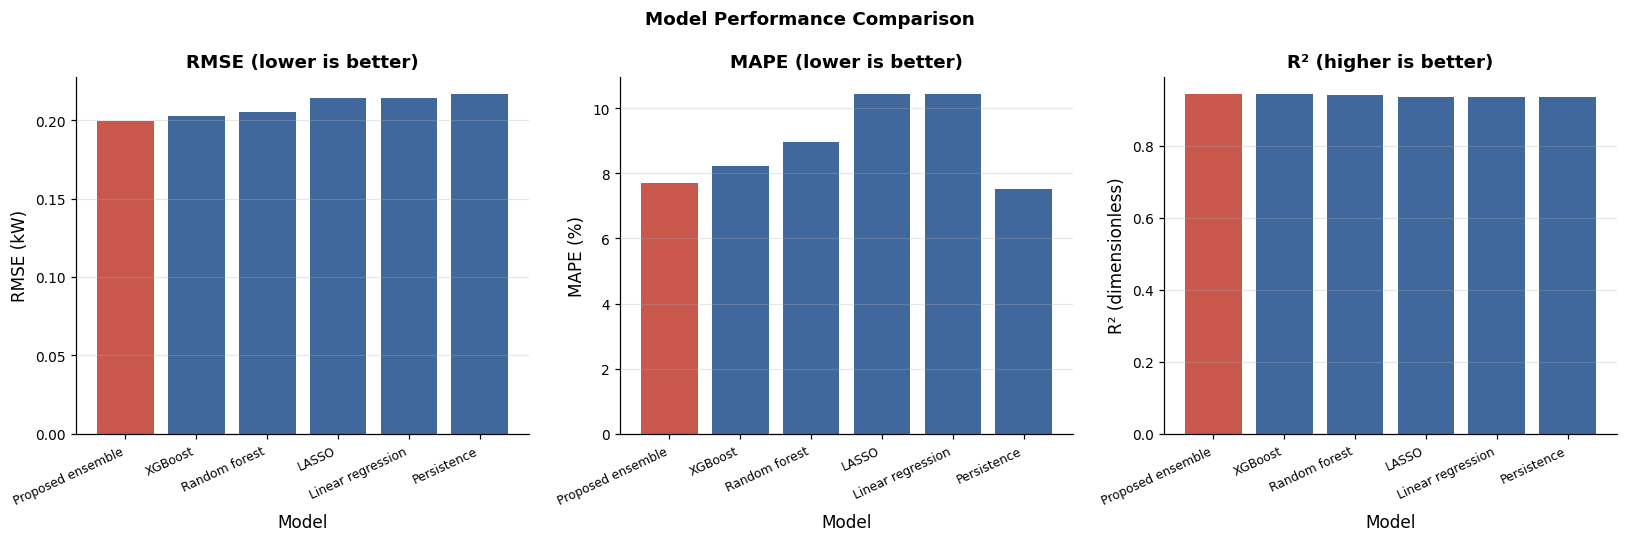

In [19]:
# Comparison of forecast accuracy across models
# MASE is included for every model evaluated at one-minute resolution. It is
# left blank for the ARIMA model, which operates on hourly aggregates and
# therefore has no comparable one-minute seasonal-naive denominator.
metric_keys = ['MAE', 'RMSE', 'R2', 'MAPE', 'sMAPE', 'DA', 'MASE']
_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})

rows = []
for name, v in results.items():
    if name in _alias:  
        continue
    row = {'Model': name}
    for k in metric_keys:
        row[k] = v['metrics'].get(k, np.nan)
    rows.append(row)

metrics_df = (
    pd.DataFrame(rows)
    .sort_values('RMSE')
    .reset_index(drop=True)
)
print("\n--- Model comparison ---")
print(metrics_df.round(5).to_string(index=False))
metrics_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)


# Comparison of the principal models on three complementary criteria.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
key_models = ['Persistence', 'LinearRegression', 'LASSO', 'RandomForest',
              'XGBoost', 'HybridStack (Proposed)']
plot_df    = metrics_df[metrics_df['Model'].isin(key_models)].copy()

for ax, metric, title, ylab in zip(
    axes,
    ['RMSE', 'MAPE', 'R2'],
    ['RMSE (lower is better)', 'MAPE (lower is better)', 'R² (higher is better)'],
    ['RMSE (kW)', 'MAPE (%)', 'R² (dimensionless)'],
):
    bars = ax.bar(
        range(len(plot_df)),
        plot_df[metric].values,
        color=[PALETTE['secondary'] if m == 'HybridStack (Proposed)' else PALETTE['primary']
               for m in plot_df['Model']],
        alpha=0.85,
    )
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(
        [m.replace('LinearRegression', 'Linear regression')
          .replace('RandomForest', 'Random forest')
          .replace('HybridStack (Proposed)', 'Proposed ensemble')
          for m in plot_df['Model']],
        rotation=25, ha='right', fontsize=8
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylab)
    ax.set_xlabel('Model')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig_pub('model_comparison_chart')
plt.show()


In [20]:
# Test of equal predictive accuracy


def diebold_mariano(y_true, pred_a, pred_b, h=1, power=2):

    y_true = np.asarray(y_true, dtype='float64')
    e_a = np.abs(y_true - np.asarray(pred_a, dtype='float64'))**power
    e_b = np.abs(y_true - np.asarray(pred_b, dtype='float64'))**power
    d   = e_a - e_b
    n   = len(d)
    dbar = float(d.mean())
    dc   = d - dbar
    L = max(h - 1, int(round(n ** (1/3))))  # truncation lag
    lrv = float(np.mean(dc**2))
    for l in range(1, L + 1):
        w_l = 1.0 - l / (L + 1)  # Bartlett kernel weight
        lrv += 2.0 * w_l * float(np.mean(dc[l:] * dc[:-l]))
    lrv = max(lrv, 1e-300)
    dm  = dbar / np.sqrt(lrv / n)
    dm *= np.sqrt((n + 1 - 2*h + h*(h - 1)/n) / n)  # small-sample correction
    p   = 2.0 * (1.0 - stats.t.cdf(abs(dm), df=n - 1))
    return float(dm), float(p)

def dm_test_wilcoxon(y_true, y_pred_a, y_pred_b):
    """Wilcoxon signed-rank test on the loss differential."""
    d = (y_true - y_pred_a)**2 - (y_true - y_pred_b)**2
    if np.all(d == 0):
        return np.nan
    _, pval = wilcoxon(d, alternative='two-sided')
    return float(pval)

PROPOSED_KEY = globals().get('PROPOSED_KEY', 'HybridStack (Proposed)')
_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})

dm_rows = []
for name, v in results.items():
    if name in _alias or name in ('ARIMA', PROPOSED_KEY):
        continue
    if len(v['y_pred']) != len(y_pred_hw):
        continue
    dm_stat, dm_p = diebold_mariano(y_test, v['y_pred'], y_pred_hw, h=1)
    wil_p         = dm_test_wilcoxon(y_test, v['y_pred'], y_pred_hw)
    dm_rows.append({
        'Baseline':    name,
        'DM_stat':     round(dm_stat, 3),
        'DM_p_value':  f'{dm_p:.2e}',
        'Wilcoxon_p':  f'{wil_p:.2e}' if np.isfinite(wil_p) else 'n/a',
        'Proposed_better': 'yes' if (dm_stat > 0 and dm_p < 0.05) else 'no',
    })

dm_df = pd.DataFrame(dm_rows)
print(f"\n--- Diebold-Mariano tests against {PROPOSED_KEY} ---")

print(dm_df.to_string(index=False))
dm_df.to_csv(OUTPUT_DIR / 'diebold_mariano_tests.csv', index=False)



--- Diebold-Mariano tests against HybridStack (Proposed) ---
        Baseline  DM_stat DM_p_value Wilcoxon_p Proposed_better
     Persistence   22.385   0.00e+00   0.00e+00             yes
LinearRegression   22.549   0.00e+00   0.00e+00             yes
           LASSO   22.398   0.00e+00   0.00e+00             yes
             KNN   54.779   0.00e+00   0.00e+00             yes
    RandomForest   17.405   0.00e+00   0.00e+00             yes
         XGBoost   13.705   0.00e+00   0.00e+00             yes



--- RMSE by temporal granularity ---
Granularity             Hourly   Daily  Weekly  Monthly  Quarterly
Model                                                             
HybridStack (Proposed)  0.0247  0.0063  0.0024   0.0014     0.0004
KNN                     0.1988  0.1006  0.0836   0.0733     0.0778
LASSO                   0.0284  0.0057  0.0023   0.0020     0.0012
LinearRegression        0.0284  0.0059  0.0026   0.0022     0.0013
RandomForest            0.0249  0.0067  0.0045   0.0046     0.0037
XGBoost                 0.0251  0.0080  0.0043   0.0032     0.0028


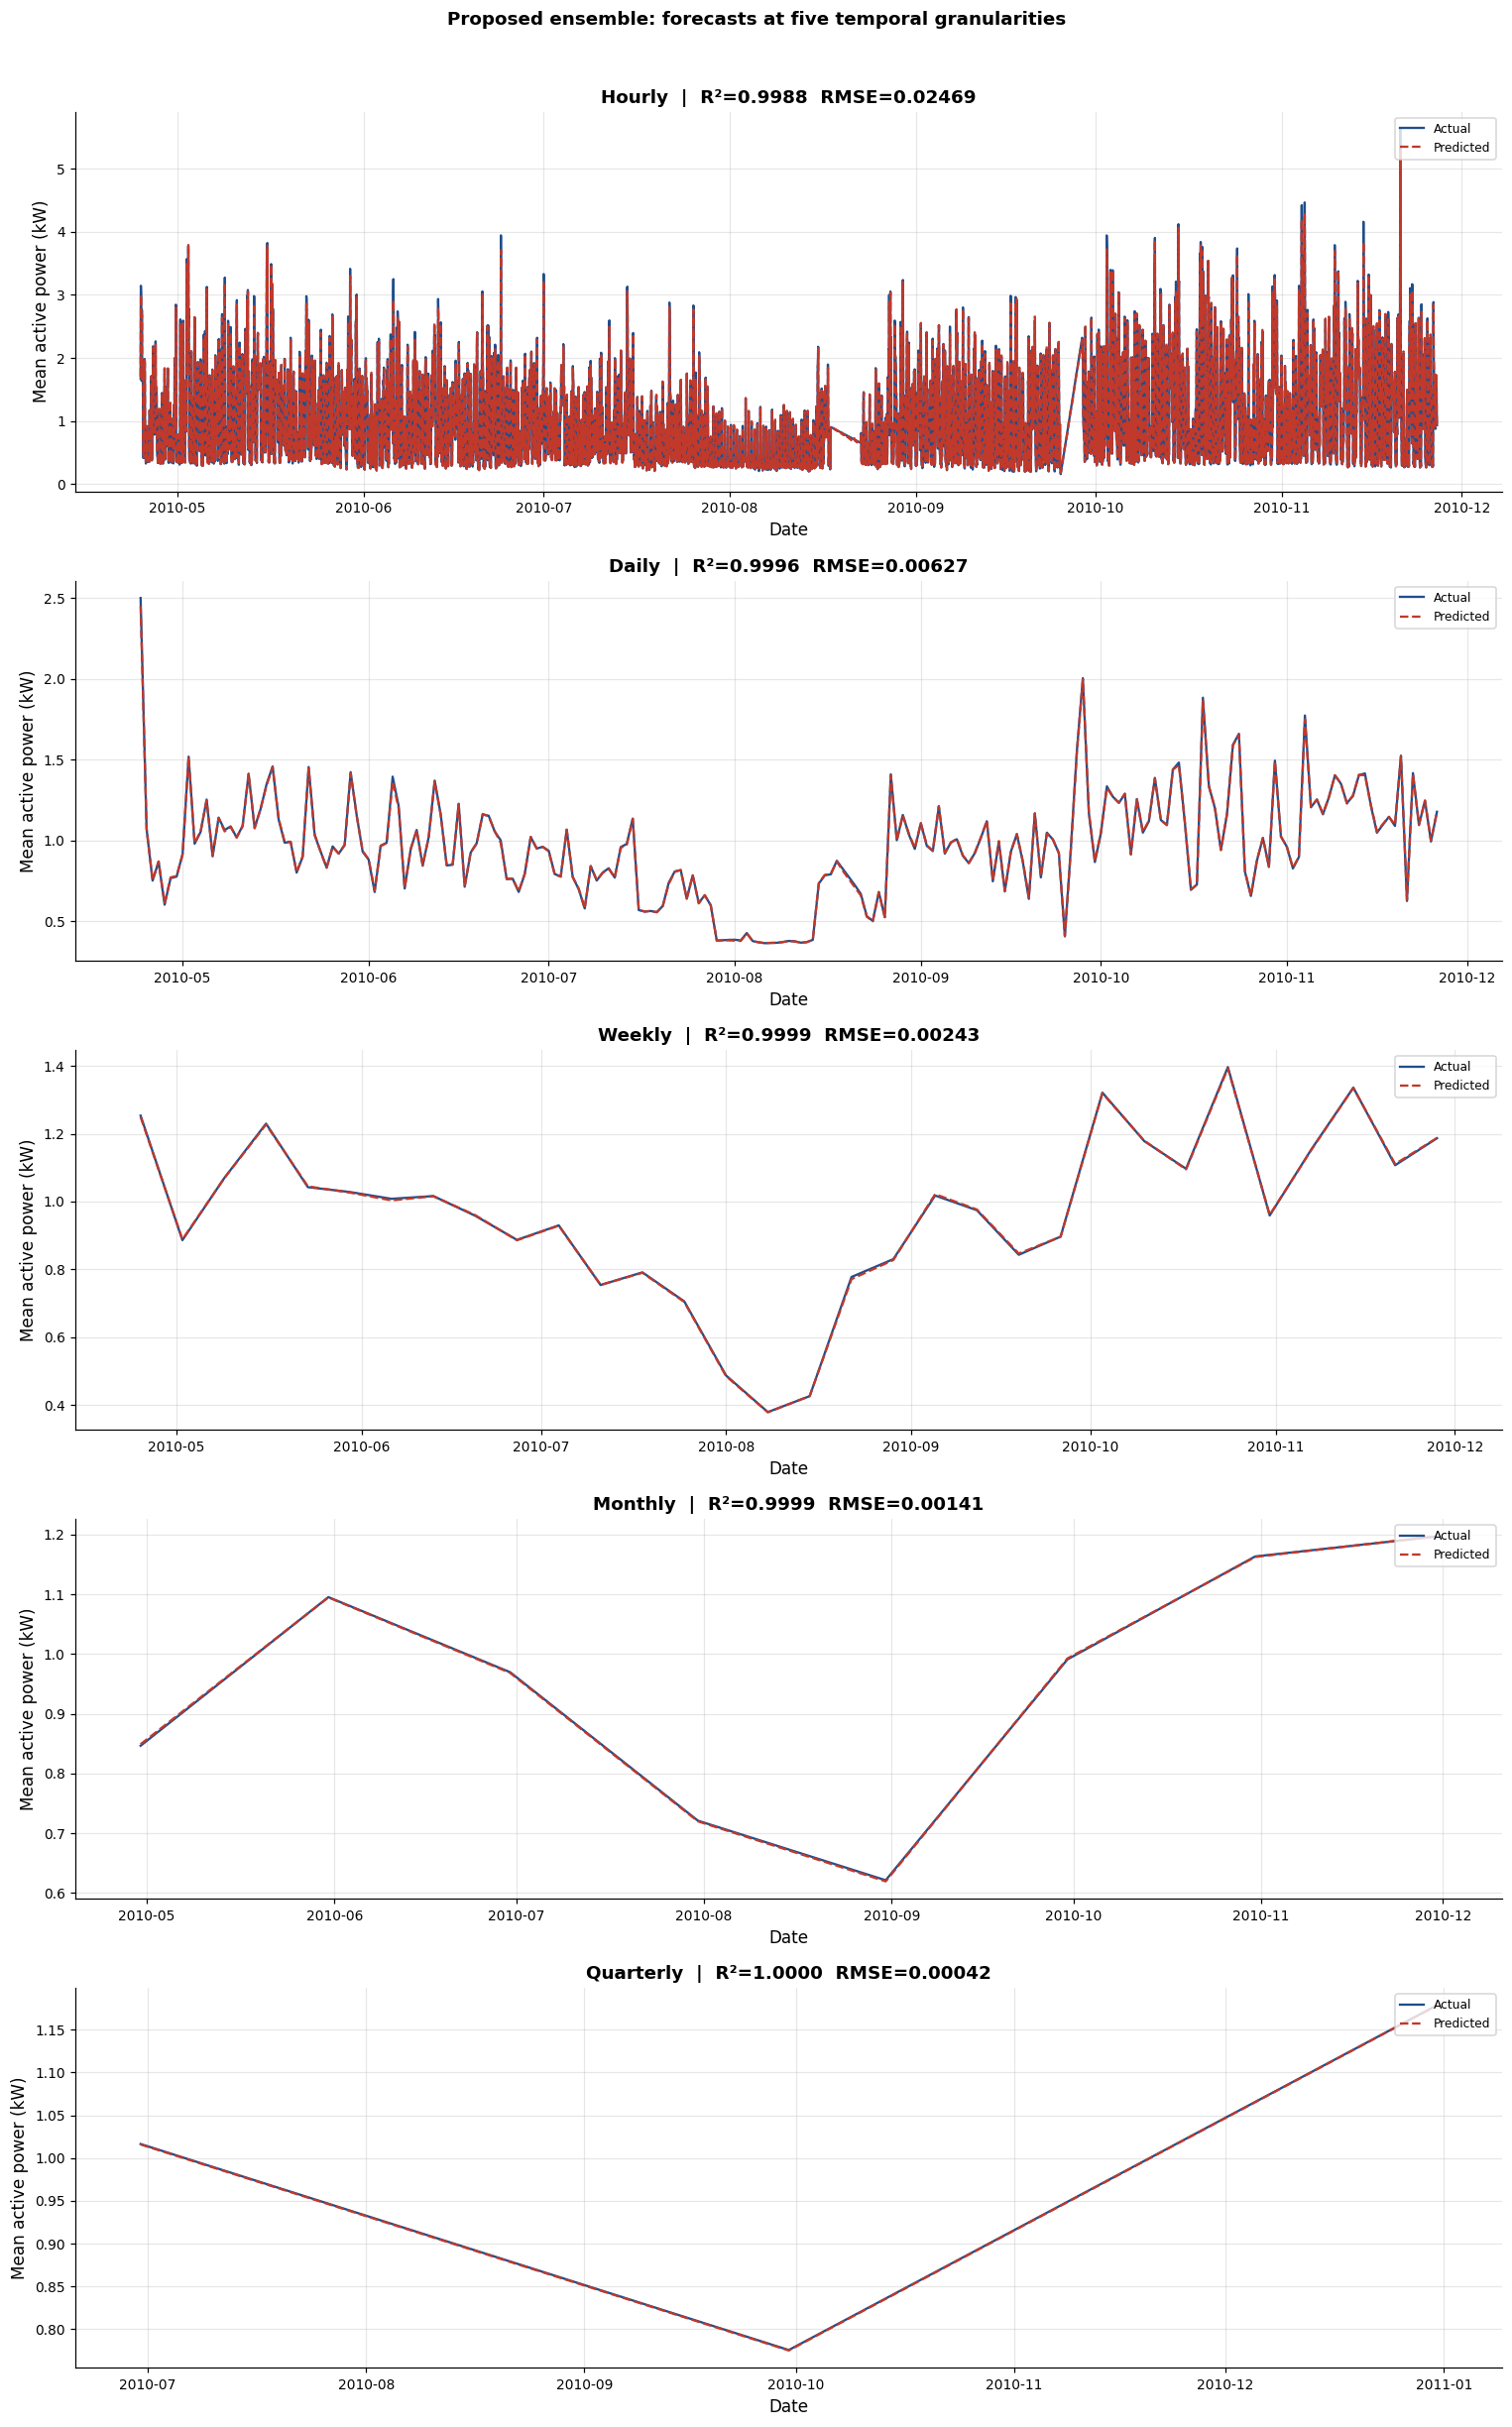

8245

In [21]:
# Multi-granularity evaluation
# The one-minute predictions are averaged to hourly, daily, weekly, monthly and
# quarterly means in order to establish whether the accuracy ordering of the
# models is preserved across temporal scales.

GRANULARITIES = {
    'Hourly':    'h',
    'Daily':     'D',
    'Weekly':    'W',
    'Monthly':   'M',
    'Quarterly': 'Q',
}

def multi_gran_metrics(y_true_arr, y_pred_arr, test_index):
    pred_df = pd.DataFrame(
        {'actual': y_true_arr, 'pred': y_pred_arr}, index=test_index
    )
    rows = []
    for name, freq in GRANULARITIES.items():
        r = pred_df.resample(freq).mean().dropna()
        if len(r) < 2:
            continue
        m = eval_metrics(r['actual'].values, r['pred'].values)
        m['Granularity'] = name
        rows.append(m)
    return pd.DataFrame(rows)

_alias = globals().get('ALIAS_KEYS', {'RawStack', 'HW+Stack+Fourier'})
multi_rows = []
for name, v in results.items():

    if name == 'ARIMA' or name == 'Persistence' or name in _alias:
        continue
    g = multi_gran_metrics(y_test, v['y_pred'], test_df.index)
    g.insert(0, 'Model', name)
    multi_rows.append(g)

multi_df = (
    pd.concat(multi_rows, ignore_index=True)
    .sort_values(['Granularity', 'RMSE'])
)
print("\n--- RMSE by temporal granularity ---")
pivot_rmse = multi_df.pivot_table(
    index='Model', columns='Granularity',
    values='RMSE', aggfunc='first'
)[list(GRANULARITIES.keys())]
print(pivot_rmse.round(4).to_string())
multi_df.to_csv(OUTPUT_DIR / 'multi_granularity_metrics.csv', index=False)

# Forecast plot at each granularity
pred_full = pd.DataFrame(
    {'actual': y_test, 'predicted': y_pred_hw}, index=test_df.index
)
fig, axes = plt.subplots(5, 1, figsize=(14, 22))
for ax, (label, freq) in zip(axes, GRANULARITIES.items()):
    r = pred_full.resample(freq).mean().dropna()
    ax.plot(r.index, r['actual'],    label='Actual',    lw=1.5, color=PALETTE['primary'])
    ax.plot(r.index, r['predicted'], label='Predicted', lw=1.5,
            color=PALETTE['secondary'], ls='--')
    m = eval_metrics(r['actual'].values, r['predicted'].values)
    ax.set_title(
        f"{label}  |  R²={m['R2']:.4f}  RMSE={m['RMSE']:.5f}",
        fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylabel('Mean active power (kW)'); ax.set_xlabel('Date'); ax.grid(alpha=0.3)
plt.suptitle('Proposed ensemble: forecasts at five temporal granularities',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
savefig_pub('multi_granularity_forecasts')
plt.show()
del pred_full; gc.collect()



 5-minute resolution
  Rows (post-FE): 414,477   Train/Val/Test: 290,133/62,172/62,172   Features: 16
  Proposed regime: five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)   (fit 36s)
  Model                 RMSE       R²    MAPE%
  --------------------------------------------
  Seasonal-naive      0.9696  -0.3685    96.18
  RandomForest        0.3366   0.8351    23.99
  XGBoost             0.3386   0.8331    23.73
  Proposed            0.3355   0.8361    22.41   (improves on both references)
  Skill against the seasonal naive: +65.4% reduction in RMSE

 Hourly resolution
  Rows (post-FE): 34,397   Train/Val/Test: 24,077/5,160/5,160   Features: 16
  Proposed regime: five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)   (fit 6s)
  Model                 RMSE       R²    MAPE%
  --------------------------------------------
  Seasonal-naive      0.7467  -0.1314    65.51
  RandomForest        0.4573   0.5757    43.93
  XGBoost             0.4588   0

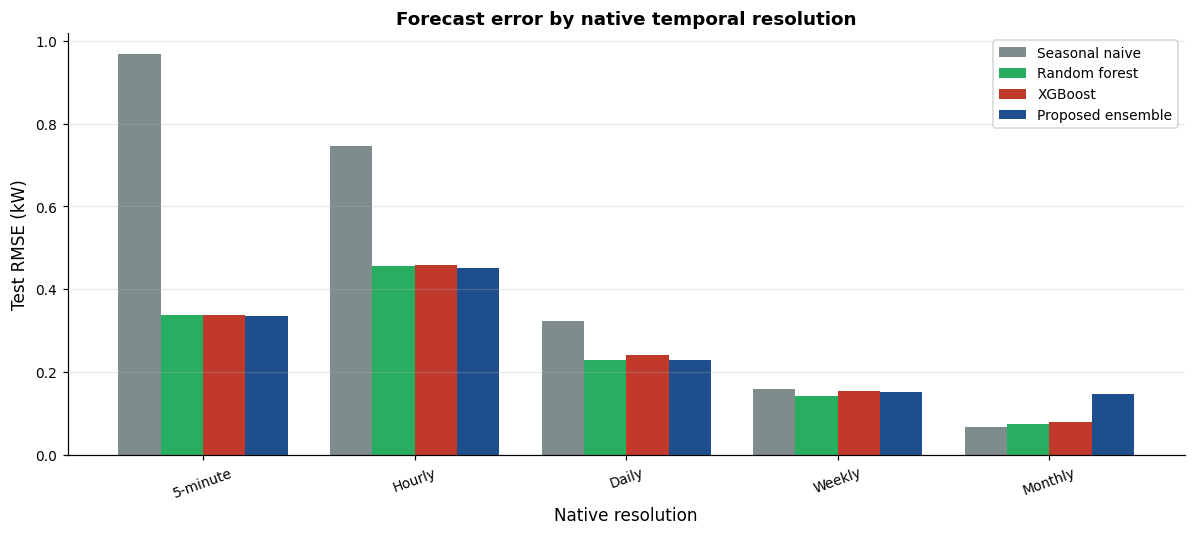

2848

In [22]:
# Forecasting at six native temporal resolutions
# At one-minute resolution the comparison is dominated by persistence, since
# the immediately preceding observation accounts for most of the variance. The
# contribution of the proposed ensemble is therefore examined at coarser native
# resolutions, where calendar and seasonal structure carries more of the signal.
# At each resolution a seasonal-naive reference, a random forest, a gradient-
# boosted model and the proposed ensemble are trained on the same target. The
# complexity of the ensemble is matched to the available sample size, and the
# seasonal-naive reference alone is reported where the sample is too small to
# support a learned model. All features are shifted by at least one step and
# all splits are chronological.

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor

# Configuration for each resolution.
RES_SPECS = {
    '5min':    dict(freq='5min', label='5-minute', lags=[1, 3, 6, 12, 288],
                    rolls=[12, 288],  seas=288),  # 288 steps = 1 day
    'hourly':  dict(freq='h',    label='Hourly',   lags=[1, 2, 3, 24, 168],
                    rolls=[24, 168],  seas=24),  # 24 steps = 1 day
    'daily':   dict(freq='D',    label='Daily',    lags=[1, 2, 7, 14, 30],
                    rolls=[7, 30],    seas=7),  # 7 steps = 1 week
    'weekly':  dict(freq='W',    label='Weekly',   lags=[1, 2, 4, 52],
                    rolls=[4, 52],    seas=52),  # 52 steps = 1 year
    'monthly': dict(freq='MS',   label='Monthly',  lags=[1, 2, 3, 12],
                    rolls=[3, 12],    seas=12),  # 12 steps = 1 year
    'yearly':  dict(freq='YS',   label='Yearly',   lags=[1, 2],
                    rolls=[2],        seas=1),
}

# Sample-size thresholds, counted after feature construction and the removal
# of rows with incomplete lag history.
MIN_ROWS_FULL   = 250  
MIN_ROWS_MEDIUM = 120  
MIN_ROWS_SIMPLE = 30   

def _build_res_frame(freq, lags, rolls):
    """Aggregate the target to `freq` and construct features from past values."""
    s = df[TARGET].resample(freq).mean().dropna()
    d = pd.DataFrame({TARGET: s})
    idx = d.index

    # Calendar / seasonal encodings appropriate to the resolution
    if freq in ('5min', 'h'):
        d['hr_sin'] = np.sin(2 * np.pi * idx.hour / 24)
        d['hr_cos'] = np.cos(2 * np.pi * idx.hour / 24)
    if freq in ('5min', 'h', 'D'):
        d['dow_sin'] = np.sin(2 * np.pi * idx.dayofweek / 7)
        d['dow_cos'] = np.cos(2 * np.pi * idx.dayofweek / 7)
    # Annual seasonality is informative at every resolution.
    d['moy_sin'] = np.sin(2 * np.pi * (idx.month - 1) / 12)
    d['moy_cos'] = np.cos(2 * np.pi * (idx.month - 1) / 12)

    # Lags
    for L in lags:
        d[f'lag_{L}'] = d[TARGET].shift(L)

    # Rolling statistics, computed on the shifted series
    sh = d[TARGET].shift(1)
    for w in rolls:
        d[f'rmean_{w}'] = sh.rolling(w, min_periods=1).mean()
        d[f'rstd_{w}']  = sh.rolling(w, min_periods=1).std()

    # First difference
    d['diff1'] = d[TARGET].shift(1) - d[TARGET].shift(2)

    return d.dropna().astype('float32', errors='ignore')

def _blend_predict(bases, meta, Xtr, ytr, Xva, yva, Xte):
 
    Xtr, ytr = np.asarray(Xtr), np.asarray(ytr)
    Xva, yva = np.asarray(Xva), np.asarray(yva)
    Xte = np.asarray(Xte)
    fitted = [clone(est).fit(Xtr, ytr) for _nm, est in bases]
    B_va = np.column_stack([m.predict(Xva) for m in fitted])
    B_te = np.column_stack([m.predict(Xte) for m in fitted])

    meta_fit = clone(meta).fit(B_va, yva)
    blend_va = meta_fit.predict(B_va)
    blend_rmse = float(np.sqrt(np.mean((blend_va - yva) ** 2)))

    base_rmses = [float(np.sqrt(np.mean((B_va[:, j] - yva) ** 2)))
                  for j in range(len(bases))]
    best_j = int(np.argmin(base_rmses))

    def _cal(p_va, p_te):
        a, b = np.linalg.lstsq(np.column_stack([p_va, np.ones_like(p_va)]), yva, rcond=None)[0]
        return a * p_te + b
    if blend_rmse <= base_rmses[best_j]:
        return _cal(blend_va, meta_fit.predict(B_te)), False
    return _cal(B_va[:, best_j], B_te[:, best_j]), True

def _fit_proposed(Xtr, ytr, Xva, yva, Xte, n_rows):
    """Fit the proposed ensemble at a complexity matched to the sample size."""
    nn_ridge = Ridge(alpha=1.0, positive=True)  # non-negative combination weights
    if n_rows >= MIN_ROWS_FULL:
        bases = [
            ('xgb', XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
                                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                 tree_method='hist', objective='reg:squarederror',
                                 random_state=RANDOM_STATE, n_jobs=-1)),
            ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                   subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                   min_child_samples=20, random_state=RANDOM_STATE,
                                   n_jobs=-1, verbose=-1)),
            ('cat', CatBoostRegressor(iterations=400, learning_rate=0.05, depth=7,
                                      l2_leaf_reg=3.0, loss_function='RMSE',
                                      random_seed=RANDOM_STATE, verbose=False,
                                      allow_writing_files=False)),
            ('et', ExtraTreesRegressor(n_estimators=200, min_samples_leaf=3,
                                       max_features='sqrt', random_state=RANDOM_STATE,
                                       n_jobs=-1)),
            ('rf', RandomForestRegressor(n_estimators=200, max_depth=14,
                                         min_samples_leaf=3, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
        ]
        base_tag = 'five learners (XGBoost, LightGBM, CatBoost, extra trees, random forest)'
    elif n_rows >= MIN_ROWS_MEDIUM:
        bases = [
            ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                 subsample=0.9, reg_lambda=2.0, tree_method='hist',
                                 objective='reg:squarederror',
                                 random_state=RANDOM_STATE, n_jobs=-1)),
            ('et', ExtraTreesRegressor(n_estimators=200, min_samples_leaf=2,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
            ('ridge', Ridge(alpha=1.0)),
            ('rf', RandomForestRegressor(n_estimators=150, max_depth=12,
                                         min_samples_leaf=3, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
        ]
        base_tag = 'four learners (XGBoost, extra trees, ridge, random forest)'
    else:  
        bases = [
            ('ridge', Ridge(alpha=1.0)),
            ('et', ExtraTreesRegressor(n_estimators=150, min_samples_leaf=2,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ]
        base_tag = 'two learners (ridge, extra trees)'

    yp, fell_back = _blend_predict(bases, nn_ridge, Xtr, ytr, Xva, yva, Xte)
    regime = base_tag + (' [fallback to best single learner]' if fell_back else '')
    return yp, regime

def _run_resolution(key):
    spec = RES_SPECS[key]
    print(f'\n{"="*64}\n {spec["label"]} resolution\n{"="*64}')

    d = _build_res_frame(spec['freq'], spec['lags'], spec['rolls'])
    N = len(d)
    if N == 0:
        print('  No data after aggregation: resolution finer than the source.')
        return None

    feats = [c for c in d.columns if c != TARGET]
    tr_e, va_e = int(N * 0.70), int(N * 0.85)
    trd, vad, ted = d.iloc[:tr_e], d.iloc[tr_e:va_e], d.iloc[va_e:]
    print(f'  Rows (post-FE): {N:,}   Train/Val/Test: {len(trd):,}/{len(vad):,}/{len(ted):,}'
          f'   Features: {len(feats)}')

    if len(ted) < 2:
        print(f'  Only {len(ted)} test observation(s); insufficient to evaluate.')
        return None

    ytr = trd[TARGET].to_numpy('float32')
    yte = ted[TARGET].to_numpy('float32')

 
    seas = max(1, min(spec['seas'], len(d) - 1))
    naive_pred = d[TARGET].shift(seas).to_numpy('float32')[va_e:]
    m_naive = eval_metrics(yte, np.nan_to_num(naive_pred, nan=float(ytr.mean())),
                           y_train_ref=ytr, seasonal_period=seas)

    row = {'Resolution': spec['label'], 'N': N, 'N_test': len(ted),
           'Naive_RMSE': m_naive['RMSE']}

    # Where the sample is too small to support a learned model, only the
    # seasonal-naive reference is reported.
    if N < MIN_ROWS_SIMPLE:
        print(f'  {N} rows, below the threshold of {MIN_ROWS_SIMPLE}. ')
        print(f'    Seasonal-naive  RMSE={m_naive["RMSE"]:.4f}  R²={m_naive["R2"]:.4f}')
        row.update({'Regime': 'naive-only', 'RF_RMSE': np.nan, 'XGB_RMSE': np.nan,
                    'Proposed_RMSE': np.nan, 'Proposed_R2': np.nan,
                    'Proposed_MAPE': np.nan, 'beats_base': False})
        return row

    Xtr_raw, Xva_raw, Xte_raw = trd[feats], vad[feats], ted[feats]
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr_raw).astype('float32')
    Xva = sc.transform(Xva_raw).astype('float32')
    Xte = sc.transform(Xte_raw).astype('float32')
    yva = vad[TARGET].to_numpy('float32')

    # Reference learners
    rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=3,
                               max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(Xtr, ytr)
    m_rf = eval_metrics(yte, np.maximum(rf.predict(Xte), 0.0), y_train_ref=ytr,
                        seasonal_period=seas)

    xgb_b = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                         tree_method='hist', objective='reg:squarederror',
                         random_state=RANDOM_STATE, n_jobs=-1)
    xgb_b.fit(Xtr, ytr)
    m_xgb = eval_metrics(yte, np.maximum(xgb_b.predict(Xte), 0.0), y_train_ref=ytr,
                         seasonal_period=seas)

    # Proposed ensemble, at a complexity matched to the sample size
    t0 = time.time()
    yp, regime = _fit_proposed(Xtr, ytr, Xva, yva, Xte, N)
    yp = np.maximum(yp, 0.0)
    m_prop = eval_metrics(yte, yp, y_train_ref=ytr, seasonal_period=seas,
                          compute_ci=(N >= MIN_ROWS_FULL))
    print(f'  Proposed regime: {regime}   (fit {time.time()-t0:.0f}s)')

    beats = (m_prop['RMSE'] < m_rf['RMSE']) and (m_prop['RMSE'] < m_xgb['RMSE'])
    skill = (1 - m_prop['RMSE'] / m_naive['RMSE']) * 100 if m_naive['RMSE'] > 0 else np.nan

    print(f'  {"Model":<16}{"RMSE":>10}{"R²":>9}{"MAPE%":>9}')
    print(f'  {"-"*44}')
    print(f'  {"Seasonal-naive":<16}{m_naive["RMSE"]:>10.4f}{m_naive["R2"]:>9.4f}{m_naive["MAPE"]:>9.2f}')
    print(f'  {"RandomForest":<16}{m_rf["RMSE"]:>10.4f}{m_rf["R2"]:>9.4f}{m_rf["MAPE"]:>9.2f}')
    print(f'  {"XGBoost":<16}{m_xgb["RMSE"]:>10.4f}{m_xgb["R2"]:>9.4f}{m_xgb["MAPE"]:>9.2f}')
    print(f'  {"Proposed":<16}{m_prop["RMSE"]:>10.4f}{m_prop["R2"]:>9.4f}{m_prop["MAPE"]:>9.2f}'
          f'   {"(improves on both references)" if beats else "(does not improve on the references)"}')
    print(f'  Skill against the seasonal naive: {skill:+.1f}% reduction in RMSE')

    row.update({'Regime': regime.split()[0], 'RF_RMSE': m_rf['RMSE'],
                'XGB_RMSE': m_xgb['RMSE'], 'Proposed_RMSE': m_prop['RMSE'],
                'Proposed_R2': m_prop['R2'], 'Proposed_MAPE': m_prop['MAPE'],
                'Naive_skill_pct': skill, 'beats_base': bool(beats)})
    return row


multires_results = {}
for _rk in ['5min', 'hourly', 'daily', 'weekly', 'monthly', 'yearly']:
    try:
        _r = _run_resolution(_rk)
        if _r is not None:
            multires_results[_rk] = _r
    except Exception as _e:
        print(f'  {_rk} resolution failed: {type(_e).__name__}: {_e}')
    gc.collect()

# Summary table
if multires_results:
    mr_summary = pd.DataFrame(list(multires_results.values()))
    cols = ['Resolution', 'N', 'N_test', 'Naive_RMSE', 'RF_RMSE', 'XGB_RMSE',
            'Proposed_RMSE', 'Proposed_R2', 'Proposed_MAPE', 'beats_base']
    cols = [c for c in cols if c in mr_summary.columns]
    print('\n\n--- Summary across native resolutions ---')
    print(mr_summary[cols].round(4).to_string(index=False))
    mr_summary.to_csv(OUTPUT_DIR / 'multiresolution_comparison.csv', index=False)
    print('\nResults written to multiresolution_comparison.csv')



    # RMSE by resolution. The seasonal-naive reference is plotted alongside
    # the learned models, so that the resolutions at which it remains
    # competitive are visible.
    plot_df = mr_summary.dropna(subset=['Proposed_RMSE'])
    if len(plot_df) >= 2:
        fig, ax = plt.subplots(figsize=(11, 5))
        x = np.arange(len(plot_df)); w = 0.2
        ax.bar(x - 1.5*w, plot_df['Naive_RMSE'],    w, label='Seasonal naive',
               color=PALETTE['neutral'])
        ax.bar(x - 0.5*w, plot_df['RF_RMSE'],       w, label='Random forest',
               color=PALETTE['accent'])
        ax.bar(x + 0.5*w, plot_df['XGB_RMSE'],      w, label='XGBoost',
               color=PALETTE['secondary'])
        ax.bar(x + 1.5*w, plot_df['Proposed_RMSE'], w, label='Proposed ensemble',
               color=PALETTE['primary'])
        ax.set_xticks(x); ax.set_xticklabels(plot_df['Resolution'], rotation=20)
        ax.set_ylabel('Test RMSE (kW)')
        ax.set_xlabel('Native resolution')
        ax.set_title('Forecast error by native temporal resolution', fontweight='bold')
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        savefig_pub('multiresolution_rmse')
        plt.show()
else:
    print('No resolution produced a model result.')
gc.collect()


Computing SHAP values for each base learner ...
  xgb ...
    shape=(500, 68)
  lgbm ...
    shape=(500, 68)
  catboost ...
    shape=(500, 68)
  rf ...
    shape=(500, 68)

Combiner            : NNLSBlend
Combination weights : {'xgb': 0.0, 'lgbm': 0.5043276781478168, 'catboost': 0.04539153479660015, 'rf': 0.4502807870555831}

Attribution matrix  : (500, 68)
Explained model     : full ensemble, weights {'xgb': 0.0, 'lgbm': 0.5043276781478168, 'catboost': 0.04539153479660015, 'rf': 0.4502807870555831}
Base value          : 1.1041 kW

Local-accuracy check ...
  Reconstructed forecast against the ensemble forecast:
    maximum absolute error : 2.84e-14 kW
    mean absolute error    : 4.92e-15 kW
    instances within 0.01 kW : 500 of 500
  The decomposition reproduces the ensemble forecast for every
  instance to within single-precision tolerance.


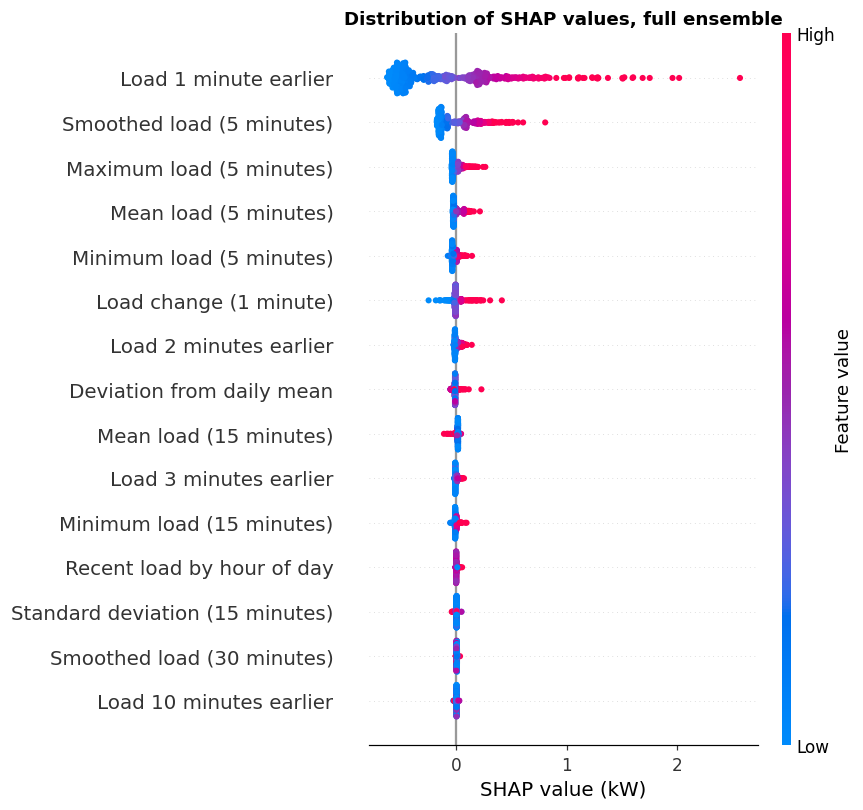

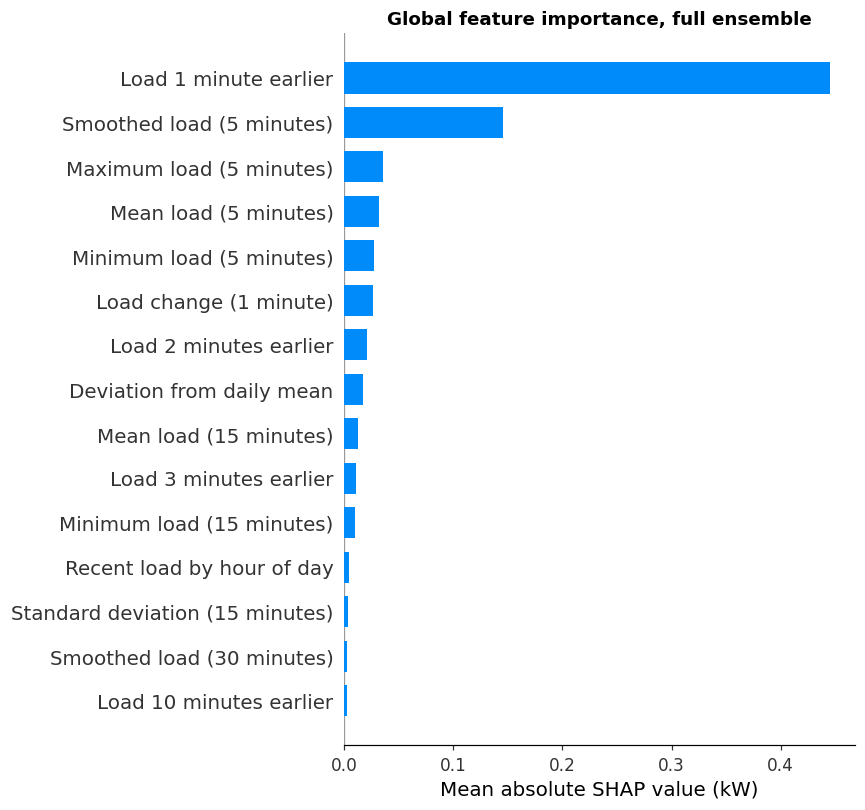


--- Ten most important features by mean absolute SHAP value ---
                         Feature             Feature_label  Mean_abs_SHAP  SHAP_Variance  SHAP_Std
       Global_active_power_lag_1     Load 1 minute earlier        0.44562        0.27466   0.52408
       Global_active_power_ewm_5 Smoothed load (5 minutes)        0.14524        0.02956   0.17192
  Global_active_power_roll_max_5  Maximum load (5 minutes)        0.03566        0.00227   0.04761
 Global_active_power_roll_mean_5     Mean load (5 minutes)        0.03211        0.00179   0.04228
  Global_active_power_roll_min_5  Minimum load (5 minutes)        0.02755        0.00070   0.02654
                  diff_lag1_lag2    Load change (1 minute)        0.02645        0.00270   0.05193
       Global_active_power_lag_2    Load 2 minutes earlier        0.02077        0.00077   0.02778
               gap_vs_daily_mean Deviation from daily mean        0.01707        0.00034   0.01852
Global_active_power_roll_mean_15    Mean loa

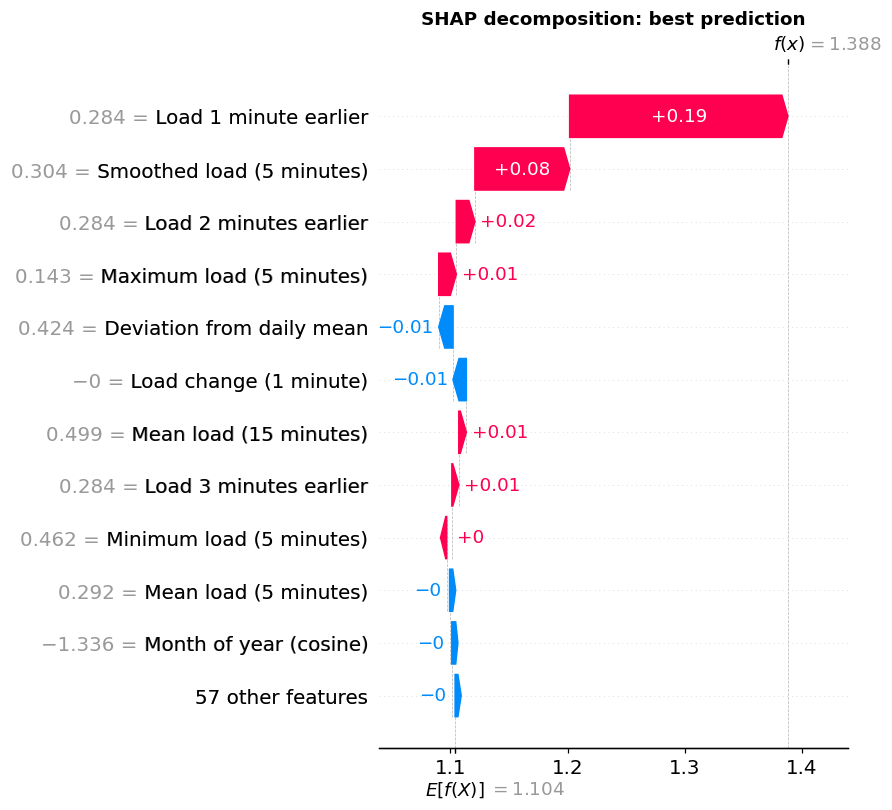

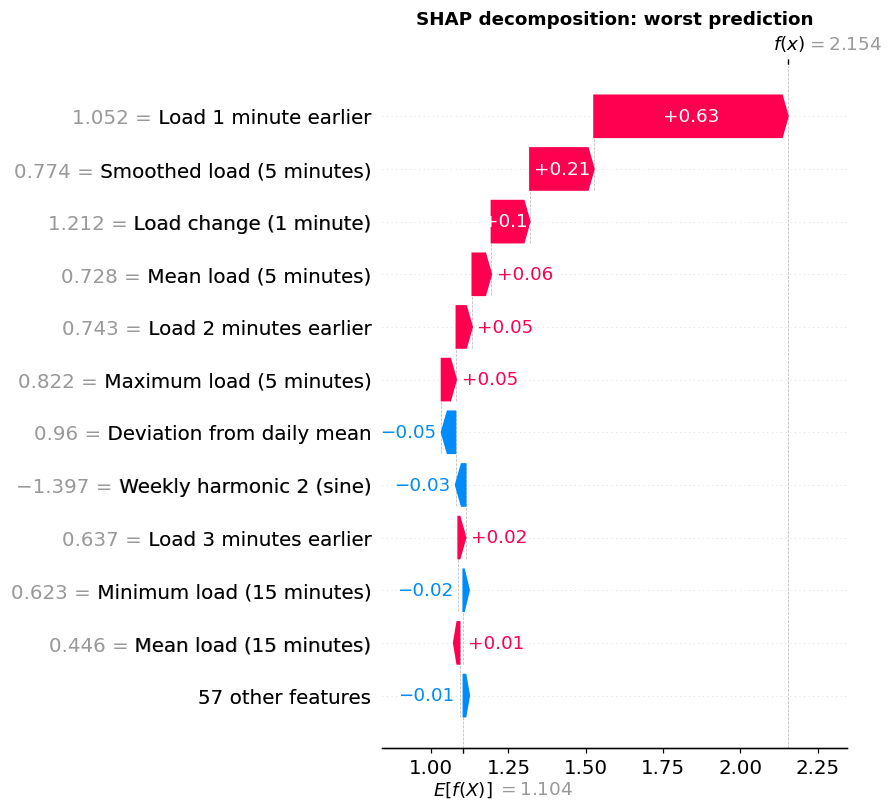

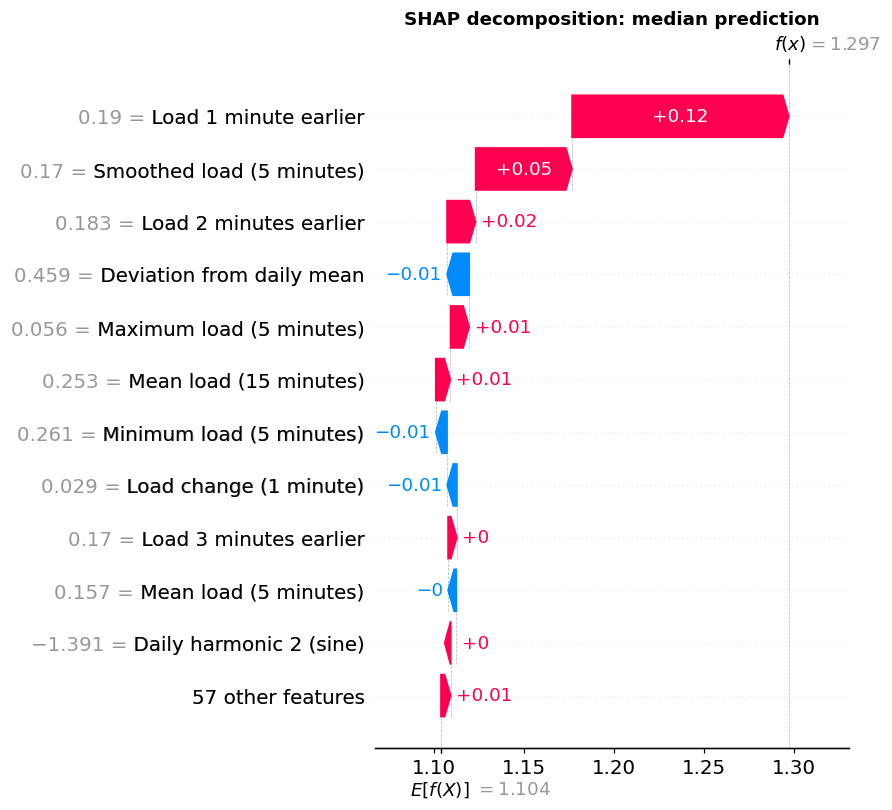


SHAP analysis of the full ensemble complete.


In [23]:
# SHAP attribution for the full ensemble
# SHAP values are computed for each base learner with the tree explainer and
# weighted by the coefficients of the convex combination

N_SHAP   = 500
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_idx_arr = rng_shap.choice(len(X_test_df), size=N_SHAP, replace=False)
X_shap   = X_test_df.iloc[shap_idx_arr].reset_index(drop=True)
y_shap   = y_test[shap_idx_arr]

# SHAP values for each base learner.
print('Computing SHAP values for each base learner ...')
_base_shap = {}
_base_ev   = {}
for name, est in FINAL_MODEL.named_estimators_.items():
    print(f'  {name} ...')
    _expl = shap.TreeExplainer(est)
    _sv   = _expl.shap_values(X_shap)
    if isinstance(_sv, list):
        _sv = _sv[0]
    _base_shap[name] = _sv
    _base_ev[name]   = float(np.ravel(_expl.expected_value)[0])  # expected value of this learner
    print(f'    shape={_sv.shape}')

# Coefficients of the combiner.
_meta = FINAL_MODEL.final_estimator_
if hasattr(_meta, 'coef_'):
    _raw_weights = list(_meta.coef_)
    _meta_type   = type(_meta).__name__
else:
    _raw_weights = list(_meta.feature_importances_)
    _meta_type   = 'XGBRegressor'
meta_weights = {
    name: float(w)
    for name, w in zip([n for n, _ in FINAL_MODEL.estimators], _raw_weights)
}
print(f'\nCombiner            : {_meta_type}')
print(f'Combination weights : {meta_weights}')

# Weighted ensemble attribution.
_names_order = [n for n, _ in FINAL_MODEL.estimators]
_coef = np.asarray(FINAL_MODEL.final_estimator_.coef_, dtype='float64')
_w_norm = {nm: float(w) for nm, w in zip(_names_order, _coef)}

ensemble_shap_values = np.zeros((N_SHAP, len(FEATURE_COLS)), dtype='float64')
for nm, w in _w_norm.items():
    if nm in _base_shap:
        ensemble_shap_values += w * _base_shap[nm]

base_val_ensemble = float(sum(_w_norm[nm] * _base_ev[nm] for nm in _names_order))

shap_values = shap.Explanation(
    values=ensemble_shap_values,
    base_values=np.full(N_SHAP, base_val_ensemble),
    data=X_shap.to_numpy(),
    feature_names=list(FEATURE_COLS),
)

print(f'\nAttribution matrix  : {shap_values.shape}')
print(f'Explained model     : full ensemble, weights {_w_norm}')
print(f'Base value          : {base_val_ensemble:.4f} kW')

# Local-accuracy check.

print('\nLocal-accuracy check ...')
_recon    = shap_values.base_values + shap_values.values.sum(axis=1)

_pred_blk = (FINAL_MODEL._base_matrix(X_shap.to_numpy()) @ _coef).astype('float64')
_add_err  = np.abs(_recon - _pred_blk)
_rel_err  = _add_err / np.maximum(np.abs(_pred_blk), 1e-6)
print(f'  Reconstructed forecast against the ensemble forecast:')
print(f'    maximum absolute error : {_add_err.max():.2e} kW')
print(f'    mean absolute error    : {_add_err.mean():.2e} kW')
print(f'    instances within 0.01 kW : '
      f'{int((_add_err < 1e-2).sum())} of {len(_add_err)}')
if _add_err.max() < 1e-2:
    print('  The decomposition reproduces the ensemble forecast for every')
    print('  instance to within single-precision tolerance.')
else:
    print('  The reconstruction error exceeds single-precision tolerance.')
    
additivity_df = pd.DataFrame({
    'max_abs_error_kW':  [_add_err.max()],
    'mean_abs_error_kW': [_add_err.mean()],
    'max_rel_error':     [_rel_err.max()],
    'n_instances':       [len(_add_err)],
})
additivity_df.to_csv(OUTPUT_DIR / 'shap_additivity_check.csv', index=False)

# Descriptive feature labels are used in every figure and table, so that no
# implementation identifier appears in the reported results.
_shap_labels = [pub_label(f) for f in FEATURE_COLS]

# Distribution of the attributions across the explained sample.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False, max_display=15,
                  feature_names=_shap_labels)
plt.title('Distribution of SHAP values, full ensemble', fontweight='bold')
plt.gca().set_xlabel('SHAP value (kW)')
plt.tight_layout()
savefig_pub('shap_beeswarm')
plt.show()

# Global importance, measured as the mean absolute attribution.
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15,
                  feature_names=_shap_labels)
plt.title('Global feature importance, full ensemble', fontweight='bold')
plt.gca().set_xlabel('Mean absolute SHAP value (kW)')
plt.tight_layout()
savefig_pub('shap_bar')
plt.show()

# SHAP variance table
shap_var_df = pd.DataFrame({
    'Feature':       X_shap.columns,
    'Mean_abs_SHAP': np.mean(np.abs(shap_values.values), axis=0),
    'SHAP_Variance': np.var(shap_values.values, axis=0),
    'SHAP_Std':      np.std(shap_values.values, axis=0),
}).sort_values('Mean_abs_SHAP', ascending=False)
shap_var_df.insert(1, 'Feature_label', [pub_label(f) for f in shap_var_df['Feature']])

print('\n--- Ten most important features by mean absolute SHAP value ---')
print(shap_var_df.head(10).round(5).to_string(index=False))
shap_var_df.to_csv(OUTPUT_DIR / 'shap_importance.csv', index=False)


y_shap_pred  = np.maximum(FINAL_MODEL.predict(X_shap.to_numpy()), 0.0)
err_shap     = np.abs(y_shap - y_shap_pred)
base_val_wf  = float(shap_values.base_values[0])
local_idx = {
    'Best_Prediction':   int(np.argmin(err_shap)),
    'Worst_Prediction':  int(np.argmax(err_shap)),
    'Median_Prediction': int(np.argsort(err_shap)[len(err_shap)//2]),
}

for label, idx in local_idx.items():
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val_wf,
        data=X_shap.iloc[idx].to_numpy(),
        feature_names=_shap_labels,
    )
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(expl, show=False, max_display=12)
    plt.title(f'SHAP decomposition: {label.replace("_", " ").lower()}',
              fontweight='bold')
    plt.tight_layout()
    savefig_pub(f'shap_waterfall_{label}')
    plt.show()

SHAP_MODEL = FINAL_MODEL.named_estimators_['xgb']
print('\nSHAP analysis of the full ensemble complete.')


Lag-resolved features : 23 of 68
Lag range             : 1 to 1440 minutes
Static features       : 45

--- Lag-resolved features by family ---
  Raw lag           : 11   ['Load 1 day earlier', 'Load 1 hour earlier', 'Load 1 minute earlier', 'Load 10 minutes earlier', 'Load 15 minutes earlier', 'Load 2 hours earlier', 'Load 2 minutes earlier', 'Load 3 minutes earlier', 'Load 30 minutes earlier', 'Load 4 hours earlier', 'Load 5 minutes earlier']
  Rolling mean      :  5   ['Mean load (1 day)', 'Mean load (1 hour)', 'Mean load (15 minutes)', 'Mean load (3 hours)', 'Mean load (5 minutes)']
  Rolling std. dev. :  5   ['Standard deviation (1 day)', 'Standard deviation (1 hour)', 'Standard deviation (15 minutes)', 'Standard deviation (3 hours)', 'Standard deviation (5 minutes)']
  Memory gap        :  2   ['Change from previous day', 'Deviation from daily mean']
  Total             : 23 of 68 model features

Attribution carried by lag-resolved features : 67.0%
Attribution carried by static fe

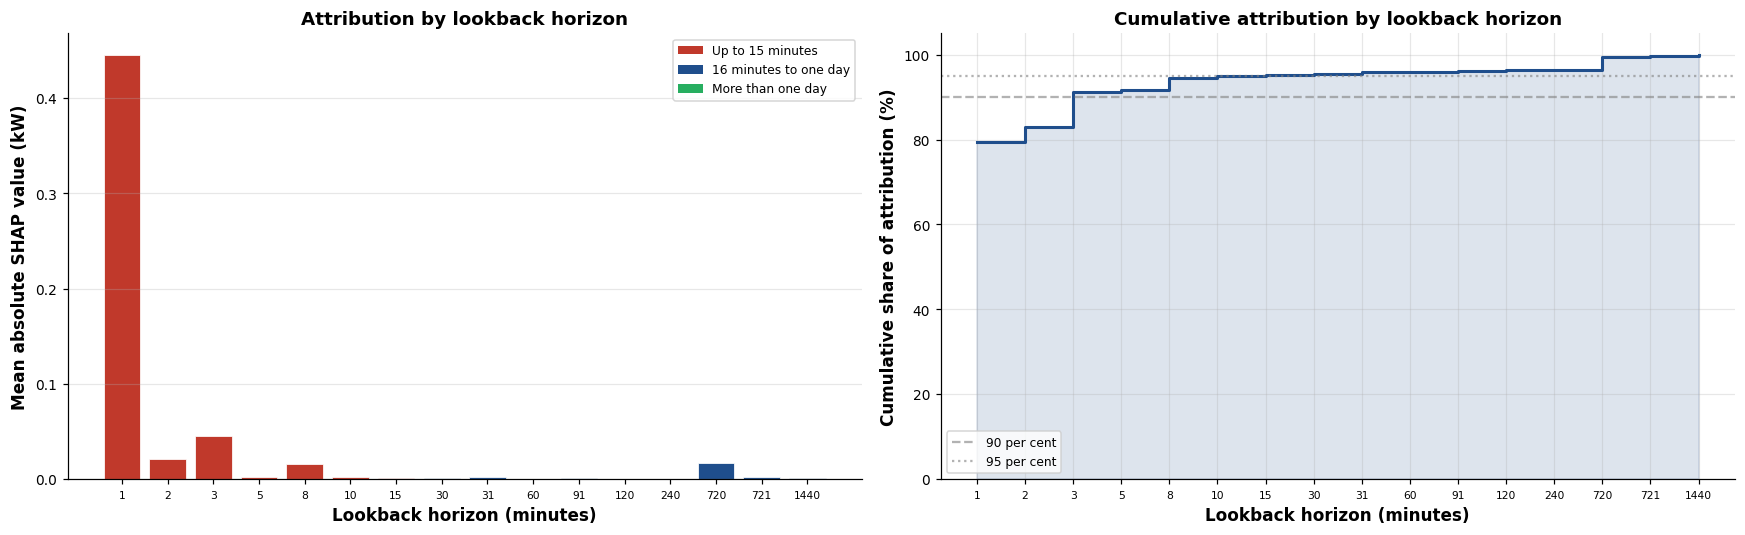

  90% of the attribution lies within 3 minutes
  95% of the attribution lies within 15 minutes
  99% of the attribution lies within 720 minutes


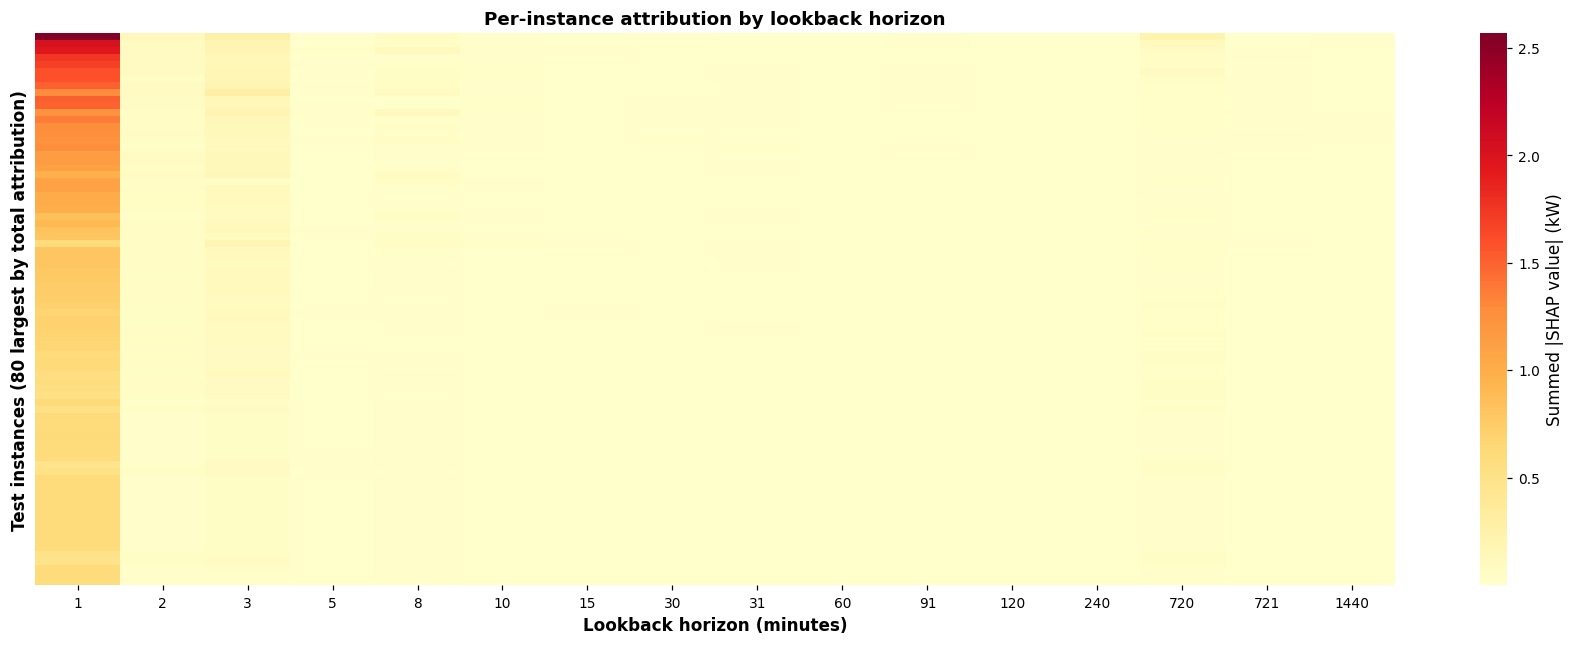


--- Lookback horizon of the ten most important features ---
Feature                                                Rank     Lookback
Load 1 minute earlier                                     1        1 min
Smoothed load (5 minutes)                                 2       static
Maximum load (5 minutes)                                  3       static
Mean load (5 minutes)                                     4        3 min
Minimum load (5 minutes)                                  5       static
Load change (1 minute)                                    6       static
Load 2 minutes earlier                                    7        2 min
Deviation from daily mean                                 8      720 min
Mean load (15 minutes)                                    9        8 min
Load 3 minutes earlier                                   10        3 min

Lag profile written to temporal_shap_summary.csv

--- Memory horizon ---
  Model                  : I(t) = A exp(-t / tau), fitted at l

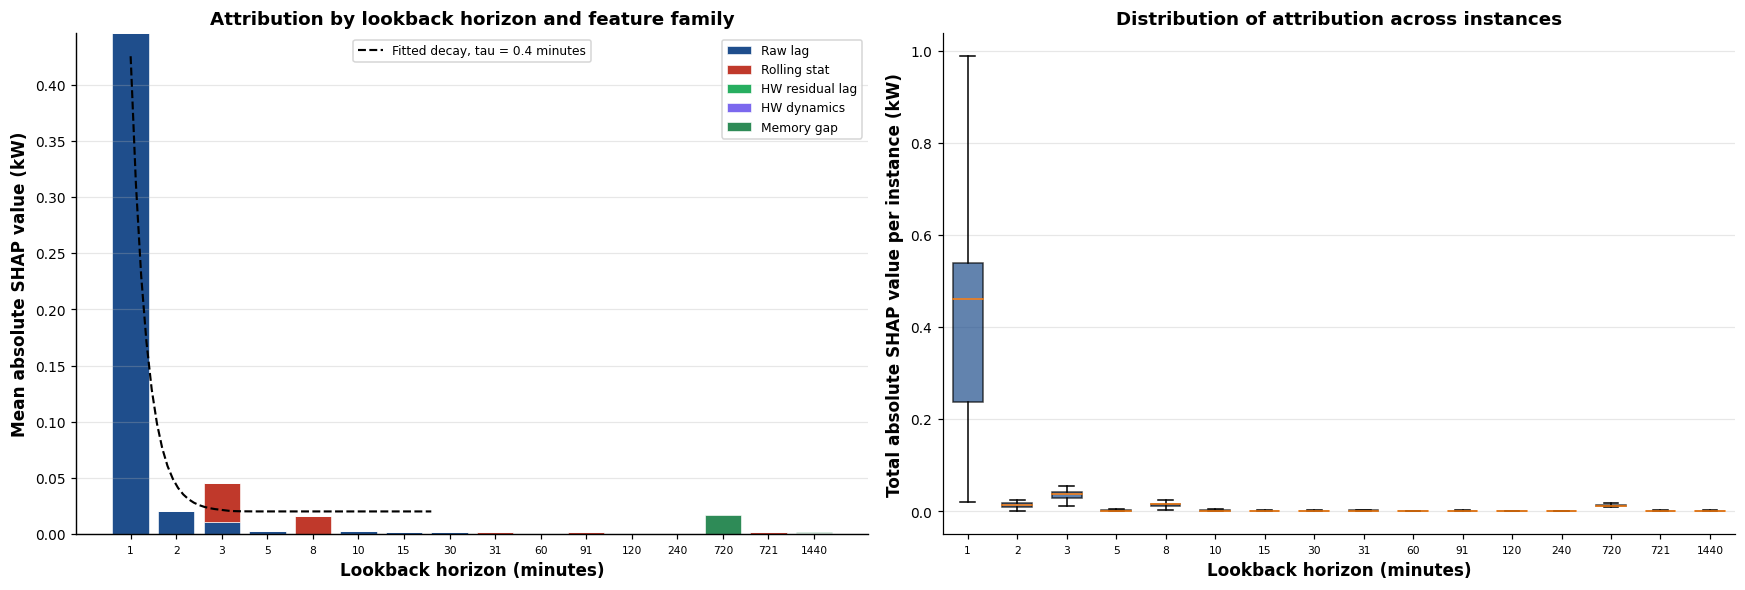

Stratified table written to temporal_shap_family_stratified.csv

 Summary of the temporal attribution analysis
The temporal attribution analysis of the proposed ensemble shows that 67.0 per
cent of the total attributional mass is carried by lag-resolved features. The
lag importance profile is concentrated at the immediate past: a lookback of 1
minute(s) alone accounts for 79.4 per cent of the attribution assigned to lag-
resolved features. The fitted exponential decay gives a memory horizon of 0.4
minutes, with an R² of 0.99, and the normalised entropy of 0.32 indicates a
profile that is strongly concentrated. Attribution is dominated by 'Raw lag'
features at every lookback horizon, and longer-range information enters only
at the daily scale, between 720 and 1440 minutes, through the 'Memory gap'
family. The rolling and exponentially weighted summaries therefore act as
variance-reducing aggregates of the same short-range window rather than as
independent long-memory channels. This resu

In [24]:
# Temporal SHAP analysis:

def extract_lag(feature_name: str) -> Optional[int]:

    import re
    m = re.search(r'_lag_(\d+)$', feature_name)
    if m:
        return int(m.group(1))
    m = re.search(r'_roll_(?:mean|std)_(\d+)$', feature_name)
    if m:
        w = int(m.group(1))
        return max(1, w // 2 + 1)
    if 'hw_residual_momentum' in feature_name:
        return 2
    if 'hw_trend_velocity' in feature_name:
        return 2
    if 'hw_trend_acceleration' in feature_name:
        return 3
    # The memory-gap features are anchored at their reference horizon rather
    # than at the current minute.
    if feature_name == 'gap_vs_yesterday':
        return 1440
    if feature_name == 'gap_vs_last_week':
        return 10080
    if feature_name == 'gap_vs_daily_mean':
        return 720
    if feature_name == 'gap_vs_weekly_mean':
        return 5040
    return None

lag_map = {f: extract_lag(f) for f in FEATURE_COLS}
lag_map = {f: l for f, l in lag_map.items() if l is not None}

temporal_features = list(lag_map.keys())
static_features   = [f for f in FEATURE_COLS if f not in lag_map]

print(f"Lag-resolved features : {len(lag_map)} of {len(FEATURE_COLS)}")
print(f"Lag range             : {min(lag_map.values())} to {max(lag_map.values())} minutes")
print(f"Static features       : {len(static_features)}")


import re as _re_lagmap
_lag_families = {'Raw lag': [], 'Rolling mean': [], 'Rolling std. dev.': [],
                 'Memory gap': [], 'Other lag-mapped': []}
for _f in temporal_features:
    if _re_lagmap.search(r'_lag_\d+$', _f):
        _lag_families['Raw lag'].append(_f)
    elif _re_lagmap.search(r'_roll_mean_\d+$', _f):
        _lag_families['Rolling mean'].append(_f)
    elif _re_lagmap.search(r'_roll_std_\d+$', _f):
        _lag_families['Rolling std. dev.'].append(_f)
    elif _f.startswith('gap_vs_'):
        _lag_families['Memory gap'].append(_f)
    else:
        _lag_families['Other lag-mapped'].append(_f)
print('\n--- Lag-resolved features by family ---')
for _fam, _feats in _lag_families.items():
    if _feats:
        print(f'  {_fam:<18}: {len(_feats):>2}   {sorted(pub_label(f) for f in _feats)}')
_n_lagmapped = sum(len(v) for v in _lag_families.values())
print(f'  {"Total":<18}: {_n_lagmapped} of {len(FEATURE_COLS)} model features')
assert _n_lagmapped == len(lag_map), 'lag-map reconciliation mismatch'

# Aggregation of the attributions at each lag.

shap_mean_abs = pd.Series(
    np.mean(np.abs(shap_values.values), axis=0),
    index=FEATURE_COLS,
)

temporal_importance: Dict[int, float] = {}
for feat, lag in lag_map.items():
    if feat in shap_mean_abs.index:
        temporal_importance[lag] = temporal_importance.get(lag, 0.0) + shap_mean_abs[feat]

ti_series = pd.Series(temporal_importance).sort_index()

total_shap  = shap_mean_abs.sum()
temp_shap   = ti_series.sum()
static_shap = shap_mean_abs[static_features].sum()
print(f"\nAttribution carried by lag-resolved features : {temp_shap/total_shap*100:.1f}%")
print(f"Attribution carried by static features       : {static_shap/total_shap*100:.1f}%")

# Lag importance profile and its cumulative share.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Attribution at each lag
ax = axes[0]
lags        = ti_series.index.tolist()
importances = ti_series.values

# The colour bands correspond to the sub-quarter-hour, intra-day and
# multi-day regimes of the lag set.
bar_colors = [
    PALETTE['secondary'] if l <= 15
    else PALETTE['primary']  if l <= 1440
    else PALETTE['accent']
    for l in lags
]
ax.bar(range(len(lags)), importances, color=bar_colors, edgecolor='white', lw=0.5)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([str(l) for l in lags], fontsize=7)
ax.set_xlabel('Lookback horizon (minutes)', fontweight='bold')
ax.set_ylabel('Mean absolute SHAP value (kW)', fontweight='bold')
ax.set_title('Attribution by lookback horizon', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=PALETTE['secondary'], label='Up to 15 minutes'),
    Patch(facecolor=PALETTE['primary'],   label='16 minutes to one day'),
    Patch(facecolor=PALETTE['accent'],    label='More than one day'),
]
ax.legend(handles=legend_els, fontsize=8)

# (b) Cumulative share of attribution
ax2 = axes[1]
cumulative = ti_series.cumsum() / ti_series.sum() * 100
ax2.step(range(len(cumulative)), cumulative.values, where='post',
         color=PALETTE['primary'], lw=2)
ax2.fill_between(range(len(cumulative)), cumulative.values,
                 step='post', alpha=0.15, color=PALETTE['primary'])
ax2.axhline(90, ls='--', color='gray', alpha=0.6, label='90 per cent')
ax2.axhline(95, ls=':',  color='gray', alpha=0.6, label='95 per cent')
ax2.set_xticks(range(len(cumulative)))
ax2.set_xticklabels([str(l) for l in cumulative.index.tolist()], fontsize=7)
ax2.set_xlabel('Lookback horizon (minutes)', fontweight='bold')
ax2.set_ylabel('Cumulative share of attribution (%)', fontweight='bold')
ax2.set_title('Cumulative attribution by lookback horizon', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3); ax2.set_ylim(0, 105)

plt.tight_layout()
savefig_pub('temporal_shap_profile')
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    cumulative_normed = ti_series.cumsum() / ti_series.sum()
    lag_at_thresh = cumulative_normed[cumulative_normed >= threshold].index[0]
    print(f"  {threshold*100:.0f}% of the attribution lies within {lag_at_thresh} minutes")

# Per-instance attribution by lag.

unique_lags  = sorted(temporal_importance.keys())
heatmap_data = np.zeros((N_SHAP, len(unique_lags)), dtype='float32')

for j, lag in enumerate(unique_lags):
    feats_at_lag = [f for f, l in lag_map.items() if l == lag and f in X_shap.columns]
    if not feats_at_lag:
        continue
    feat_indices = [list(X_shap.columns).index(f) for f in feats_at_lag]
    heatmap_data[:, j] = np.sum(
        np.abs(shap_values.values[:, feat_indices]), axis=1
    )

row_order = np.argsort(heatmap_data.sum(axis=1))[::-1]

fig, ax = plt.subplots(figsize=(16, 6))
n_show = min(80, N_SHAP)
sns.heatmap(
    heatmap_data[row_order[:n_show]],
    xticklabels=[str(l) for l in unique_lags],
    yticklabels=False,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Summed |SHAP value| (kW)'},
)
ax.set_xlabel('Lookback horizon (minutes)', fontweight='bold')
ax.set_ylabel(f'Test instances ({n_show} largest by total attribution)',
              fontweight='bold')
ax.set_title('Per-instance attribution by lookback horizon', fontweight='bold')
plt.tight_layout()
savefig_pub('temporal_shap_heatmap')
plt.show()

# Lookback horizon of the features that rank highest on global importance.

top10_std   = shap_var_df.head(10)['Feature'].tolist()
top_lag_std = [lag_map.get(f, None) for f in top10_std]

print("\n--- Lookback horizon of the ten most important features ---")
print(f"{'Feature':<44} {'Rank':>14} {'Lookback':>12}")
for i, (f, l) in enumerate(zip(top10_std, top_lag_std), 1):
    lag_str = f"{l} min" if l is not None else "static"
    print(f"{pub_label(f):<44} {i:>14d} {lag_str:>12}")

temporal_summary_df = pd.DataFrame({
    'Lag_step_min': list(ti_series.index),
    'Importance':   list(ti_series.values),
    'Cumulative_%': list(ti_series.cumsum() / ti_series.sum() * 100),
}).round(5)
temporal_summary_df.to_csv(OUTPUT_DIR / 'temporal_shap_summary.csv', index=False)
print("\nLag profile written to temporal_shap_summary.csv")


from scipy.optimize import curve_fit

_short_mask = ti_series.index <= 24
_t_fit = ti_series.index[_short_mask].to_numpy(dtype='float64')
_y_fit = ti_series.values[_short_mask].astype('float64')
_y_fit = np.maximum(_y_fit, 1e-12)  # guard against log(0)

def _exp_decay(t, A, tau):
    return A * np.exp(-t / tau)

try:
    _p0 = [float(_y_fit[0]), 3.0]
    popt, _ = curve_fit(_exp_decay, _t_fit, _y_fit, p0=_p0, maxfev=10_000)
    A_hat, tau_hat = float(popt[0]), float(popt[1])
    # R² of fit on log scale (more informative for a decay)
    _y_pred = _exp_decay(_t_fit, A_hat, tau_hat)
    _ss_res = float(np.sum((_y_fit - _y_pred) ** 2))
    _ss_tot = float(np.sum((_y_fit - _y_fit.mean()) ** 2))
    r2_decay = 1.0 - _ss_res / _ss_tot if _ss_tot > 0 else float('nan')
except Exception as e:
    A_hat, tau_hat, r2_decay = float('nan'), float('nan'), float('nan')
    print(f"  Decay fit failed: {e}")

print("\n--- Memory horizon ---")
print(f"  Model                  : I(t) = A exp(-t / tau), fitted at lags of")
print(f"                           24 minutes or less")
print(f"  A (peak attribution)   : {A_hat:.5f}")
print(f"  tau (memory horizon)   : {tau_hat:.3f} minutes")
print(f"  R² of the fit          : {r2_decay:.4f}")
print(f"  After {tau_hat:.1f} minutes the marginal attribution has fallen to")
print(f"  a fraction 1/e, or about 37 per cent, of its peak.")

# Normalised entropy of the lag profile, on a scale from zero to one. A value
# near zero indicates that attribution is concentrated at a single lookback
# horizon; a value near one indicates that it is spread evenly across horizons.

_p = ti_series.values / ti_series.values.sum()
_p_pos = _p[_p > 0]
H_raw  = float(-np.sum(_p_pos * np.log(_p_pos)))
H_norm = H_raw / float(np.log(len(_p_pos))) if len(_p_pos) > 1 else 0.0

print("\n--- Concentration of attribution across lookback horizons ---")
print(f"  Normalised entropy : {H_norm:.4f}   (0 = single horizon, 1 = uniform)")
if H_norm < 0.4:
    _regime = "strongly concentrated"
elif H_norm < 0.7:
    _regime = "moderately concentrated, dominated by short memory"
else:
    _regime = "diffuse, with memory at several scales"
print(f"  Memory regime      : {_regime}")



def _family(feat: str) -> str:
    if feat.startswith('gap_vs_'):            return 'Memory gap'
    if 'hw_residual_lag' in feat:             return 'HW residual lag'
    if feat in ('hw_residual_momentum',
                'hw_trend_velocity',
                'hw_trend_acceleration'):     return 'HW dynamics'
    if '_roll_' in feat:                      return 'Rolling stat'
    if '_lag_' in feat:                       return 'Raw lag'
    return 'Other'

FAMILY_ORDER  = ['Raw lag', 'Rolling stat', 'HW residual lag',
                 'HW dynamics', 'Memory gap']
FAMILY_COLORS = {
    'Raw lag':         PALETTE['primary'],
    'Rolling stat':    PALETTE['secondary'],
    'HW residual lag': PALETTE['accent'],
    'HW dynamics':     '#7B68EE',
    'Memory gap':      '#2E8B57',
}

# Matrix of attribution by lag and feature family.
strat = pd.DataFrame(0.0, index=sorted(set(lag_map.values())),
                     columns=FAMILY_ORDER)
for feat, lag in lag_map.items():
    if feat in shap_mean_abs.index:
        fam = _family(feat)
        if fam in strat.columns:
            strat.loc[lag, fam] += float(shap_mean_abs[feat])

print("\n--- Mean absolute attribution by lag and feature family ---")
print(strat.round(5).to_string())

# Instance-level distribution of attribution at each lag.
lag_dist_arrays, lag_dist_labels = [], []
for lag in unique_lags:
    feats_at_lag = [f for f, l in lag_map.items()
                    if l == lag and f in X_shap.columns]
    if not feats_at_lag:
        continue
    idxs = [list(X_shap.columns).index(f) for f in feats_at_lag]
    lag_dist_arrays.append(
        np.sum(np.abs(shap_values.values[:, idxs]), axis=1)
    )
    lag_dist_labels.append(str(lag))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# (a) Attribution by lag, stratified by feature family
ax = axes[0]
bottom = np.zeros(len(strat))
for fam in FAMILY_ORDER:
    ax.bar(range(len(strat)), strat[fam].values, bottom=bottom,
           label=fam, color=FAMILY_COLORS[fam], edgecolor='white', lw=0.4)
    bottom += strat[fam].values
ax.set_xticks(range(len(strat)))
ax.set_xticklabels([str(l) for l in strat.index], fontsize=7)
ax.set_xlabel('Lookback horizon (minutes)', fontweight='bold')
ax.set_ylabel('Mean absolute SHAP value (kW)', fontweight='bold')
ax.set_title('Attribution by lookback horizon and feature family',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# (b) Instance-level distribution of attribution at each horizon
ax2 = axes[1]
bp = ax2.boxplot(lag_dist_arrays, labels=lag_dist_labels,
                 patch_artist=True, showfliers=False, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE['primary']); patch.set_alpha(0.7)
ax2.set_xlabel('Lookback horizon (minutes)', fontweight='bold')
ax2.set_ylabel('Total absolute SHAP value per instance (kW)',
               fontweight='bold')
ax2.set_title('Distribution of attribution across instances',
              fontweight='bold')
ax2.tick_params(axis='x', labelsize=7)
ax2.grid(axis='y', alpha=0.3)

# The fitted decay is overlaid on the stratified panel as a visual check.
try:
    _tt = np.linspace(1, min(24, max(strat.index)), 200)
    _ax_top = ax.twinx()
    _ax_top.plot(np.interp(_tt, strat.index, range(len(strat))),
                 _exp_decay(_tt, A_hat, tau_hat),
                 color='black', ls='--', lw=1.4,
                 label=f'Fitted decay, tau = {tau_hat:.1f} minutes')
    _ax_top.set_yticks([])
    _ax_top.legend(loc='upper center', fontsize=8, frameon=True)
except Exception:
    pass

plt.tight_layout()
savefig_pub('temporal_shap_family_stratified')
plt.show()

strat_out = strat.copy()
strat_out.index.name = 'Lag_step_min'
strat_out.to_csv(OUTPUT_DIR / 'temporal_shap_family_stratified.csv')
print("Stratified table written to temporal_shap_family_stratified.csv")

# Summary of the temporal analysis, generated from the quantities computed
# above so that the figures quoted in the text match the run exactly.
print("\n" + "=" * 75)
print(" Summary of the temporal attribution analysis")
print("=" * 75)
_lag1_share = float(ti_series.iloc[0] / ti_series.sum() * 100)
_lag1_val   = int(ti_series.index[0])
_top_family_per_lag = strat.idxmax(axis=1)
_dom_family_short  = _top_family_per_lag.loc[
    [l for l in _top_family_per_lag.index if l <= 3]
].value_counts().idxmax()
_dom_family_mid = (
    _top_family_per_lag.loc[
        [l for l in _top_family_per_lag.index if 4 <= l <= 24]
    ].value_counts().idxmax()
    if any(4 <= l <= 24 for l in _top_family_per_lag.index) else 'n/a'
)
_dom_family_long = (
    _top_family_per_lag.loc[
        [l for l in _top_family_per_lag.index if l > 24]
    ].value_counts().idxmax()
    if any(l > 24 for l in _top_family_per_lag.index) else 'n/a'
)

_distinct_fams = {f for f in (_dom_family_short, _dom_family_mid,
                              _dom_family_long) if f != 'n/a'}
if len(_distinct_fams) > 1:
    _niche_sentence = (
        f"The dominant feature family differs across lookback horizons. "
        f"Attribution at three minutes and below is carried by "
        f"'{_dom_family_short}' features, between four and 24 minutes by "
        f"'{_dom_family_mid}' features, and beyond 24 minutes by "
        f"'{_dom_family_long}' features, indicating that the engineered "
        f"families occupy complementary temporal ranges. "
    )
else:
    # Compute which family carries the daily-scale (>= 720 min) signal
    _long_rows = strat.loc[[l for l in strat.index if l >= 720]]
    _long_fam  = (_long_rows.sum(axis=0).idxmax()
                  if len(_long_rows) else 'Memory gap')
    _niche_sentence = (
        f"Attribution is dominated by '{_dom_family_short}' features at every "
        f"lookback horizon, and longer-range information enters only at the "
        f"daily scale, between 720 and 1440 minutes, through the "
        f"'{_long_fam}' family. The rolling and exponentially weighted "
        f"summaries therefore act as variance-reducing aggregates of the same "
        f"short-range window rather than as independent long-memory channels. "
        f"This result is consistent with the removal of the Holt-Winters "
        f"family from the prediction path in the ablation study. "
    )

interp = (
    f"The temporal attribution analysis of the proposed ensemble shows that "
    f"{temp_shap/total_shap*100:.1f} per cent of the total attributional mass "
    f"is carried by lag-resolved features. The lag importance profile is "
    f"concentrated at the immediate past: a lookback of {_lag1_val} minute(s) "
    f"alone accounts for {_lag1_share:.1f} per cent of the attribution "
    f"assigned to lag-resolved features. The fitted exponential decay gives a "
    f"memory horizon of {tau_hat:.1f} minutes, with an R² of "
    f"{r2_decay:.2f}, and the normalised entropy of {H_norm:.2f} indicates a "
    f"profile that is {_regime}. "
    + _niche_sentence +
    f"The Holt-Winters decomposition is retained as an analysis layer, "
    f"providing trend and seasonal diagnostics and the evidence for feature "
    f"pruning, while the prediction path operates on the reduced feature set. "
    f"Taken together, these results characterise the model as short-memoried "
    f"at one-minute resolution, a regime in which the physical persistence of "
    f"appliance operation outweighs calendar seasonality."
)
import textwrap
print(textwrap.fill(interp, width=78))
print("=" * 75)


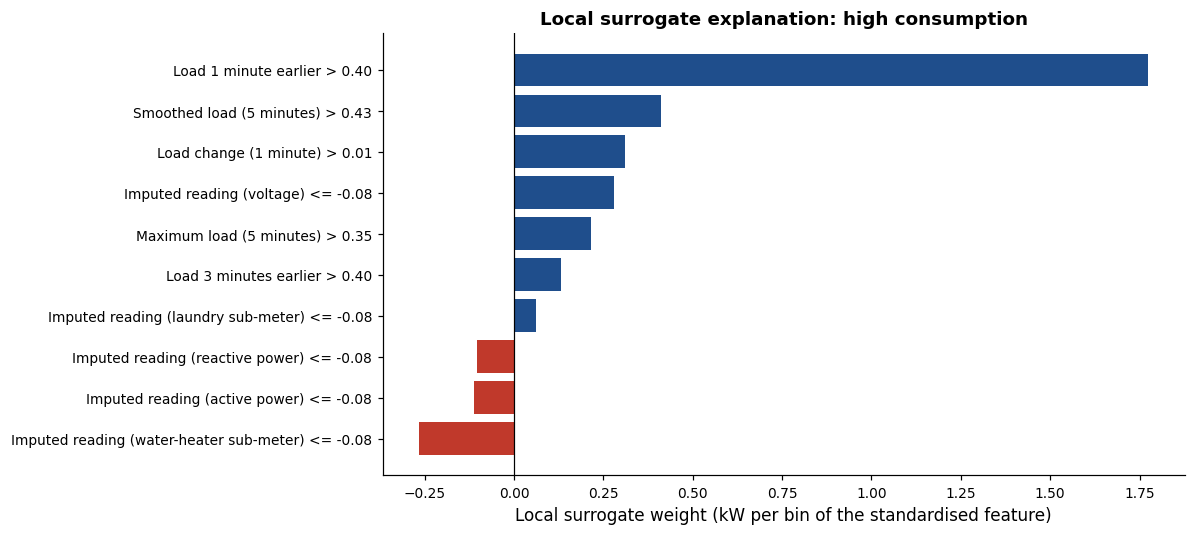

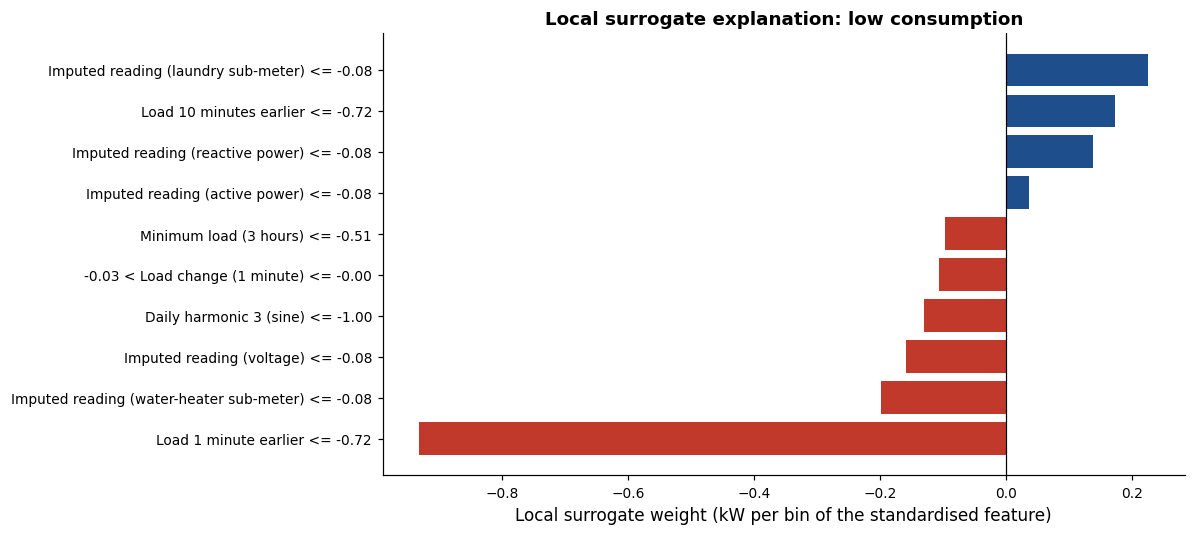

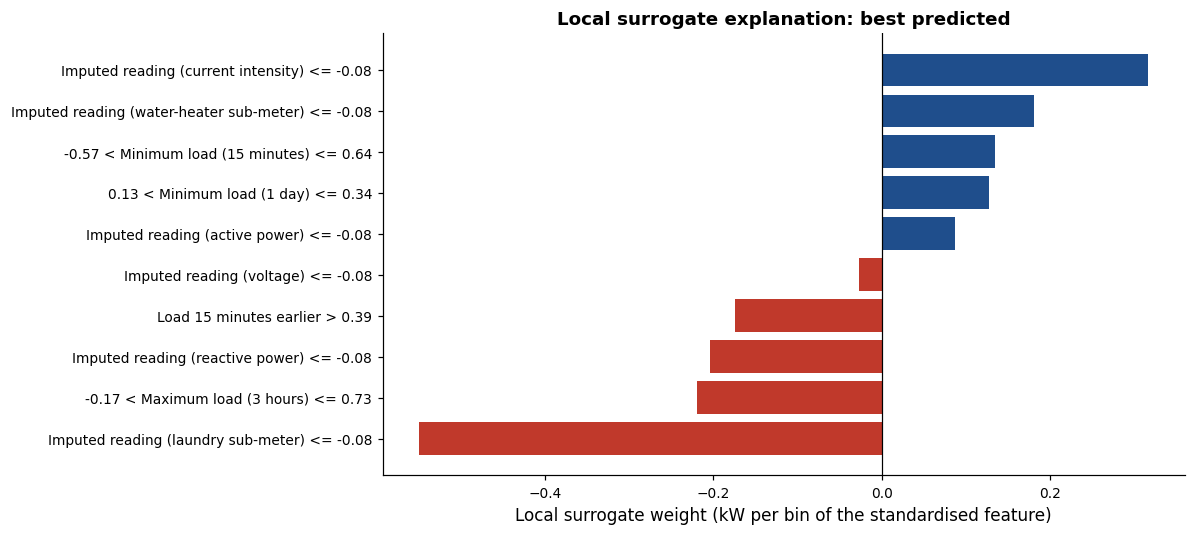

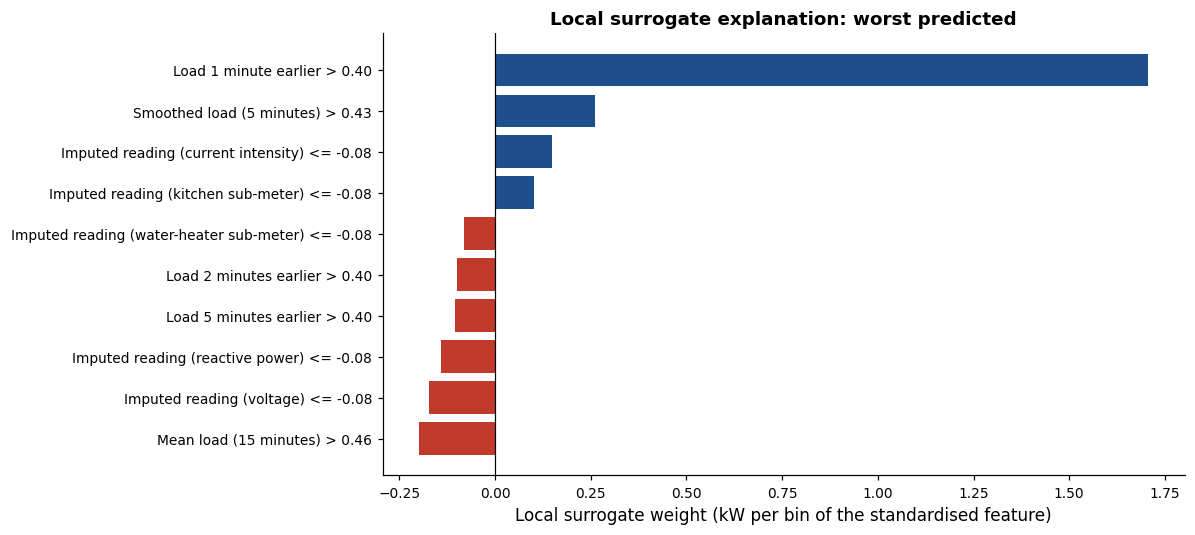

14121

In [25]:
# Local surrogate explanations
# LIME fits a linear surrogate in the neighbourhood of an individual
# prediction. It is complementary to the SHAP analysis, being locally
# faithful rather than globally consistent. To keep the comparison direct,
# both methods explain the same gradient-boosted base learner on the raw
# target. Four instances are examined: the highest and lowest observed
# demand, and the most and least accurately predicted minutes.

LIME_BG_SIZE = 3_000
rng_lime     = np.random.default_rng(RANDOM_STATE)
lime_bg_idx  = np.sort(rng_lime.choice(len(X_train), LIME_BG_SIZE, replace=False))
X_lime_bg    = X_train[lime_bg_idx]

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_bg,
    feature_names=FEATURE_COLS,
    mode='regression',
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

y_pred_test  = np.maximum(FINAL_MODEL.predict(X_test), 0.0)
err_test     = np.abs(y_test - y_pred_test)

lime_instances = {
    'High_Consumption':  int(np.argmax(y_test)),
    'Low_Consumption':   int(np.argmin(y_test)),
    'Best_Predicted':    int(np.argmin(err_test)),
    'Worst_Predicted':   int(np.argmax(err_test)),
}

# The discretised conditions returned by LIME embed the implementation feature
# names. These are translated to descriptive labels for display, while the raw
# strings are retained in lime_outputs for subsequent processing.
def _lime_display(cond):
    for _f in sorted(FEATURE_COLS, key=len, reverse=True):
        if _f in cond:
            return cond.replace(_f, pub_label(_f))
    return cond

lime_outputs = {}
for label, idx in lime_instances.items():
    exp = lime_explainer.explain_instance(
        data_row=X_test[idx],
        # The same base learner is explained here as in the SHAP analysis.
        predict_fn=lambda rows: SHAP_MODEL.predict(rows).ravel(),
        num_features=10,
        num_samples=500,
    )
    lime_df = (
        pd.DataFrame(exp.as_list(), columns=['Feature', 'Weight'])
        .sort_values('Weight')
    )
    lime_outputs[label] = lime_df

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [PALETTE['secondary'] if w < 0 else PALETTE['primary']
              for w in lime_df['Weight']]
    ax.barh([_lime_display(t) for t in lime_df['Feature']],
            lime_df['Weight'], color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Local surrogate explanation: {label.replace("_", " ").lower()}',
                 fontweight='bold')
    ax.set_xlabel('Local surrogate weight (kW per bin of the standardised feature)')
    plt.tight_layout()
    savefig_pub(f'lime_{label}')
    plt.show()

del X_lime_bg; gc.collect()


Near-constant binary features excluded from the comparison (7): ['Imputed reading (active power)', 'Imputed reading (reactive power)', 'Imputed reading (voltage)', 'Imputed reading (current intensity)', 'Imputed reading (kitchen sub-meter)', 'Imputed reading (laundry sub-meter)', 'Imputed reading (water-heater sub-meter)']

Agreement between the SHAP and local-surrogate rankings:
  All features, anchored on the fifteen highest SHAP values:
    rho = 0.0576, p = 0.6410, n = 68; not significant at the 5 per cent level
  Union of the ten highest ranked by each method:
    rho = 0.1744, p = 0.5510, n = 14; not significant at the 5 per cent level
  Overlap between the two sets of ten:
    60% (6 of 10 features shared)

  The 7 near-constant binary indicators excluded from
  the latter two measures are an artefact of the discretised
  perturbation scheme; the SHAP and permutation measures assign
  them almost no importance.

--- Agreement of the five highest ranked features ---
  By SHAP val

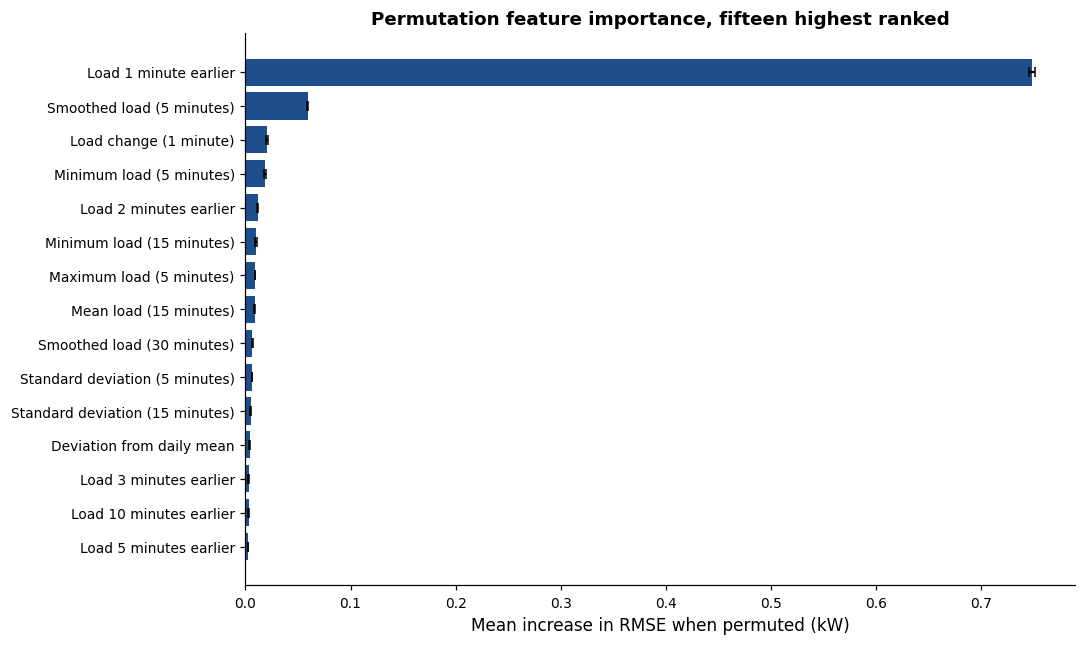

6851

In [26]:
# Agreement between attribution methods, and permutation importance
# The agreement between the SHAP and local-surrogate rankings is measured by
# the Spearman rank correlation and reported in three forms: over the fifteen
# features ranked highest by SHAP value, over the union of the ten highest
# ranked by each method, and as the overlap between the two sets of ten.
# Near-constant binary indicator columns are excluded from the latter two: the
# discretised perturbation scheme of the local surrogate assigns them large
# weights, whereas both the SHAP and permutation measures attribute them
# almost nothing. Permutation importance is computed on the same base learner
# and against the same target as the SHAP analysis.

# SHAP importance
shap_imp = pd.Series(
    np.mean(np.abs(shap_values.values), axis=0), index=X_shap.columns
).sort_values(ascending=False)

# Aggregated local-surrogate importance, averaged over the instances in which
# each feature appears.
lime_scores = pd.Series(0.0, index=FEATURE_COLS, dtype=float)
_lime_counts = pd.Series(0, index=FEATURE_COLS)
for df_lime in lime_outputs.values():
    for _, row in df_lime.iterrows():
        text = str(row['Feature'])
        for feat in FEATURE_COLS:
            if feat in text:
                lime_scores[feat] += abs(float(row['Weight']))
                _lime_counts[feat] += 1

lime_scores = lime_scores.div(_lime_counts.replace(0, np.nan)).fillna(0.0)

# Near-constant binary indicators, on which the local surrogate is unstable.
_near_const = [
    c for c in FEATURE_COLS
    if train_df[c].nunique(dropna=False) <= 2
    and train_df[c].value_counts(normalize=True, dropna=False).iloc[0] > 0.95
]
print(f"Near-constant binary features excluded from the comparison "
      f"({len(_near_const)}): {[pub_label(c) for c in _near_const]}")

lime_scores_informative = lime_scores.drop(index=_near_const, errors='ignore')

shap_imp_inf = shap_imp.drop(index=_near_const, errors='ignore')

_common_a = [f for f in shap_imp.index if f in lime_scores.index]
rho_raw, pval_raw = spearmanr(
    shap_imp[_common_a].rank(ascending=False).values,
    lime_scores[_common_a].rank(ascending=False).values)
n_raw = len(_common_a)

# Union of the ten highest ranked by each method
_shap_top10 = list(shap_imp_inf.index[:10])
_lime_top10 = list(lime_scores_informative
                   .sort_values(ascending=False).index[:10])
_union = list(dict.fromkeys(_shap_top10 + _lime_top10))
_sh_u  = shap_imp_inf.reindex(_union).fillna(0.0).rank(ascending=False)
_li_u  = lime_scores_informative.reindex(_union).fillna(0.0).rank(ascending=False)
rho_union, pval_union = spearmanr(_sh_u.values, _li_u.values)
n_union = len(_union)

# Overlap between the two sets of ten
overlap10 = len(set(_shap_top10) & set(_lime_top10)) / 10.0

_sig = lambda p: 'significant at the 5 per cent level' if p < 0.05 else 'not significant at the 5 per cent level'
print(f"\nAgreement between the SHAP and local-surrogate rankings:")
print(f"  All features, anchored on the fifteen highest SHAP values:")
print(f"    rho = {rho_raw:.4f}, p = {pval_raw:.4f}, n = {n_raw}; {_sig(pval_raw)}")
print(f"  Union of the ten highest ranked by each method:")
print(f"    rho = {rho_union:.4f}, p = {pval_union:.4f}, n = {n_union}; {_sig(pval_union)}")
print(f"  Overlap between the two sets of ten:")
print(f"    {overlap10:.0%} ({int(overlap10*10)} of 10 features shared)")
print(f"\n  The {len(_near_const)} near-constant binary indicators excluded from")
print(f"  the latter two measures are an artefact of the discretised")
print(f"  perturbation scheme; the SHAP and permutation measures assign")
print(f"  them almost no importance.")
rho, pval = float(rho_union), float(pval_union)

pd.DataFrame({
    'comparison':   ['shap_anchored_top15', 'union_top10_informative',
                     'top10_overlap'],
    'spearman_rho': [rho_raw, rho_union, np.nan],
    'p_value':      [pval_raw, pval_union, np.nan],
    'n_features':   [n_raw, n_union, np.nan],
    'overlap_frac': [np.nan, np.nan, overlap10],
}).to_csv(OUTPUT_DIR / 'shap_lime_agreement.csv', index=False)

# Permutation importance, measured as the increase in RMSE when a feature is
# randomly permuted. It is computed on the same base learner and against the
# same raw target as the SHAP analysis, on a random subsample of the test
# split.
PFI_SAMPLE = 10_000
rng_pfi    = np.random.default_rng(RANDOM_STATE)
pfi_idx    = rng_pfi.choice(len(X_test), PFI_SAMPLE, replace=False)
X_pfi      = X_test[pfi_idx]; y_pfi = y_test[pfi_idx]

pfi = permutation_importance(
    SHAP_MODEL, X_pfi, y_pfi,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)
pfi_df = pd.DataFrame({
    'Feature':        FEATURE_COLS,
    'Importance_mean': pfi.importances_mean,
    'Importance_std':  pfi.importances_std,
}).sort_values('Importance_mean', ascending=False)
pfi_df.insert(1, 'Feature_label', [pub_label(f) for f in pfi_df['Feature']])

# Agreement between the two importance measures over their five highest ranked
# features. The count is computed from the rankings rather than stated, and the
# complete permutation ranking is exported for verification.
_shap_top5 = list(shap_imp.index[:5])
_pfi_top5  = list(pfi_df['Feature'].head(5))
_shared_5  = [f for f in _shap_top5 if f in _pfi_top5]
print('\n--- Agreement of the five highest ranked features ---')
print('  By SHAP value       :', [pub_label(f) for f in _shap_top5])
print('  By permutation         :', [pub_label(f) for f in _pfi_top5])
print(f'  Shared by both methods : {len(_shared_5)} of 5, '
      f'{[pub_label(f) for f in _shared_5]}')
pd.DataFrame({'SHAP_top5': _shap_top5, 'PFI_top5': _pfi_top5,
              'n_shared_top5': [len(_shared_5)] * 5}).to_csv(
    OUTPUT_DIR / 'shap_pfi_top5_overlap.csv', index=False)

top15 = pfi_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top15['Feature_label'][::-1], top15['Importance_mean'][::-1],
    xerr=top15['Importance_std'][::-1],
    color=PALETTE['primary'], ecolor='black', capsize=3
)
ax.set_xlabel('Mean increase in RMSE when permuted (kW)')
ax.set_title('Permutation feature importance, fifteen highest ranked',
             fontweight='bold')
plt.tight_layout()
savefig_pub('permutation_feature_importance')
plt.show()

pfi_df.to_csv(OUTPUT_DIR / 'permutation_importance.csv', index=False)
del X_pfi, y_pfi; gc.collect()


In [27]:
# Combined attribution table
# The ten highest ranked features under each of the three attribution methods,
# annotated with the lookback horizon assigned by the temporal mapping.

shap_top10 = shap_var_df.head(10)[['Feature', 'Mean_abs_SHAP']].reset_index(drop=True)
shap_top10.columns = ['Feature', 'SHAP_importance']

pfi_top10  = pfi_df.head(10)[['Feature', 'Importance_mean']].reset_index(drop=True)
pfi_top10.columns  = ['Feature', 'PFI_importance']

# The local-surrogate scores exclude the near-constant indicator columns
# identified above.
_lime_src = (lime_scores_informative
             if 'lime_scores_informative' in globals() else lime_scores)
lime_top10 = (
    _lime_src.sort_values(ascending=False).head(10)
    .reset_index().rename(columns={'index': 'Feature', 0: 'LIME_score'})
)
lime_top10.columns = ['Feature', 'LIME_score']

# An outer join retains features ranked highly by only one of the methods.
xai_compare = (
    shap_top10
    .merge(pfi_top10,  on='Feature', how='outer')
    .merge(lime_top10, on='Feature', how='outer')
)
xai_compare['Temporal_lag_min'] = xai_compare['Feature'].map(lag_map).fillna('static')
xai_compare['Temporal_lag_min'] = xai_compare['Temporal_lag_min'].astype(str)
xai_compare.insert(1, 'Feature_label', [pub_label(f) for f in xai_compare['Feature']])

print("\n--- Combined feature-attribution table ---")
print(xai_compare.round(5).to_string(index=False))
xai_compare.to_csv(OUTPUT_DIR / 'xai_method_comparison.csv', index=False)

# The aggregated local-surrogate score is an absolute effect size in the units
# of the model output, per discretised bin of the standardised feature. It is
# not normalised to the unit interval, so values above one are admissible.
print('\nColumn definitions:')
print('  SHAP_importance  : mean absolute SHAP value over the explained')
print('                     sample, in kW.')
print('  PFI_importance   : mean increase in RMSE when the feature is')
print('                     permuted, in kW.')
print('  LIME_score       : mean absolute local surrogate weight in kW over')
print('                     the instances in which the feature appears; not')
print('                     normalised.')
print('  Temporal_lag_min : lookback horizon assigned by the temporal mapping;')
print('                     features marked static are not lag-resolved.')



--- Combined feature-attribution table ---
                         Feature                  Feature_label  SHAP_importance  PFI_importance  LIME_score Temporal_lag_min
       Global_active_power_lag_1          Load 1 minute earlier          0.44562         0.74849     0.95174              1.0
       Global_active_power_ewm_5      Smoothed load (5 minutes)          0.14524         0.05923     0.33672           static
  Global_active_power_roll_max_5       Maximum load (5 minutes)          0.03566         0.00920     0.21579           static
 Global_active_power_roll_mean_5          Mean load (5 minutes)          0.03211             NaN         NaN              3.0
  Global_active_power_roll_min_5       Minimum load (5 minutes)          0.02755         0.01868         NaN           static
                  diff_lag1_lag2         Load change (1 minute)          0.02645         0.02036     0.20945           static
       Global_active_power_lag_2         Load 2 minutes earlier          0

In [28]:
# Appliance-level forecasting from the sub-meter channels


APPLIANCES = {
    'Kitchen (sub-meter 1)':       'Sub_metering_1',
    'Laundry (sub-meter 2)':       'Sub_metering_2',
    'Water heating (sub-meter 3)': 'Sub_metering_3',
}
app_feat_cols = [
    c for c in FEATURE_COLS
    if c not in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
]

appliance_results = {}
for app_name, app_col in APPLIANCES.items():
    sc2   = StandardScaler()
    aX_tr = sc2.fit_transform(train_df[app_feat_cols]).astype('float32')
    aX_te = sc2.transform(test_df[app_feat_cols]).astype('float32')
    ay_tr = train_df[app_col].to_numpy(dtype='float32')
    ay_te = test_df[app_col].to_numpy(dtype='float32')

   
    zero_frac = float(np.mean(ay_tr == 0))
    print(f'{app_name}: zero readings in the training split = {zero_frac:.1%}')
    if zero_frac > 0.5:
        print(f'  Percentage error is inflated at this rate of zero readings.')

    mdl = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', objective='reg:squarederror',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    mdl.fit(aX_tr, ay_tr)
    ap = mdl.predict(aX_te)
    appliance_results[app_name] = {
        'y_true': ay_te, 'y_pred': ap,
        # Scaled by the daily seasonal naive at one-minute resolution.
        'metrics': eval_metrics(ay_te, ap, y_train_ref=ay_tr, seasonal_period=1440),
        'zero_fraction': zero_frac,
    }
    m = appliance_results[app_name]['metrics']
    print(f"{app_name}: R²={m['R2']:.4f}  RMSE={m['RMSE']:.4f}  MAPE={m['MAPE']:.1f}%")
    if m['MAPE'] > 80:
        print(f'  MAPE of {m["MAPE"]:.1f}% reflects the zero-inflated target')
    del aX_tr, aX_te; gc.collect()

app_df = pd.DataFrame([
    {'Appliance': k,
     'Zero_Frac_pct': round(v['zero_fraction']*100, 1),
     **{m: round(v['metrics'][m], 6) for m in ['MAE','RMSE','R2','MAPE']}}
    for k, v in appliance_results.items()
])
print('\n--- Appliance-level forecast accuracy ---')
print(app_df.to_string(index=False))
print('\nThe large percentage errors on the kitchen and laundry channels follow')
print('from their near-zero targets. Of the three channels, only water heating')
print('supports a forecast of practical use for demand response.')
app_df.to_csv(OUTPUT_DIR / 'appliance_metrics.csv', index=False)


Kitchen (sub-meter 1): zero readings in the training split = 91.8%
  Percentage error is inflated at this rate of zero readings.
Kitchen (sub-meter 1): R²=0.5651  RMSE=3.5267  MAPE=104.6%
  MAPE of 104.6% reflects the zero-inflated target
Laundry (sub-meter 2): zero readings in the training split = 71.3%
  Percentage error is inflated at this rate of zero readings.
Laundry (sub-meter 2): R²=0.4868  RMSE=3.2054  MAPE=88.3%
  MAPE of 88.3% reflects the zero-inflated target
Water heating (sub-meter 3): zero readings in the training split = 49.4%
Water heating (sub-meter 3): R²=0.8307  RMSE=3.4064  MAPE=66.7%

--- Appliance-level forecast accuracy ---
                  Appliance  Zero_Frac_pct      MAE     RMSE       R2       MAPE
      Kitchen (sub-meter 1)           91.8 0.739402 3.526664 0.565061 104.583487
      Laundry (sub-meter 2)           71.3 1.071909 3.205405 0.486793  88.329929
Water heating (sub-meter 3)           49.4 1.732603 3.406442 0.830728  66.699961

The large percentag

In [29]:
# Inference pipeline
# The complete feature matrix is reconstructed from a rolling buffer of at
# least 1440 recent observations, without reference to the training data frame,
# and the convex combination is then applied to the standardised features. No
# Holt-Winters model is required at inference time. The imputation indicators
# default to zero, corresponding to a clean measurement feed; a mask may be
# supplied to flag minutes whose values were imputed. The reconstructed columns
# are reconciled against those expected by the fitted scaler before prediction.
#
# Two evaluation protocols are reported:
#   one-step-ahead forecasting, the task the model was trained for, evaluated
#   over the final day of the test split; and
#   recursive forecasting over a 60-minute horizon, in which predictions are
#   fed back as inputs and the error is reported at each horizon.

_INFERENCE_EWM_SPANS = [5, 30, 60, 1440]  # must match the training configuration
_INFERENCE_K_DAILY   = globals().get('K_DAILY',  4)
_INFERENCE_K_WEEKLY  = globals().get('K_WEEKLY', 3)

def build_inference_features(
    timestamps,
    recent_history_df,
    target_col   = TARGET,
    feature_cols = None,
    missing_mask = None,  # optional: pd.Series(bool, index=timestamps)
):
    """Reconstruct the feature matrix for `timestamps` from recent history.

    The reconstruction uses only the supplied buffer of past observations, so
    that the procedure is identical to the one that would be applied to a live
    measurement feed.

    Parameters
    ----------
    timestamps        : DatetimeIndex of new prediction times (minute-level)
    recent_history_df : DataFrame holding at least 1440 minutes of past
                        indexed by DatetimeIndex, containing target_col.
    target_col        : name of the target column (default: TARGET)
    feature_cols      : feature columns to return (default: FEATURE_COLS)
    missing_mask      : optional boolean Series (index=timestamps).
                        If provided, `{target_col}_was_missing` is set to
                        1 for flagged timestamps instead of 0.
                        All other *_was_missing columns remain 0.

    Returns
    -------
    feat_df : DataFrame indexed by `timestamps`, whose columns are those of
              `feature_cols` that could be reconstructed.
    """
    if feature_cols is None:
        feature_cols = FEATURE_COLS

    # Assemble the history and add placeholder rows for the prediction times.
    combined = recent_history_df[[target_col]].copy()
   
    _ts_index = pd.DatetimeIndex(timestamps)
    _missing  = _ts_index.difference(combined.index)
    new_rows  = pd.DataFrame(index=_missing,
                              columns=[target_col], dtype='float32')
    full = pd.concat([combined, new_rows]).sort_index()

    # Calendar and cyclical encodings
    full['hour']        = full.index.hour
    full['day_of_week'] = full.index.dayofweek
    full['month']       = full.index.month
    full['is_weekend']  = (full.index.dayofweek >= 5).astype('int8')
    for (col, period) in [('hour', 24), ('day_of_week', 7), ('month', 12)]:
        suffix = col.split('_')[0] if '_' in col else col
        full[f'{suffix}_sin'] = np.sin(2*np.pi*full[col]/period).astype('float32')
        full[f'{suffix}_cos'] = np.cos(2*np.pi*full[col]/period).astype('float32')

    # Fourier basis
    mod  = full.index.hour * 60 + full.index.minute
    modw = full.index.dayofweek * 1440 + mod
    for k in range(1, _INFERENCE_K_DAILY + 1):
        ang = 2.0*np.pi*k*mod/1440.0
        full[f'fourier_d_sin_{k}'] = np.sin(ang).astype('float32')
        full[f'fourier_d_cos_{k}'] = np.cos(ang).astype('float32')
    for k in range(1, _INFERENCE_K_WEEKLY + 1):
        ang = 2.0*np.pi*k*modw/10080.0
        full[f'fourier_w_sin_{k}'] = np.sin(ang).astype('float32')
        full[f'fourier_w_cos_{k}'] = np.cos(ang).astype('float32')

    # Lags
    for lag in LAG_STEPS:
        full[f'{target_col}_lag_{lag}'] = full[target_col].shift(lag).astype('float32')

    # Rolling statistics
    shifted = full[target_col].shift(1)
    for w in ROLLING_WINDOWS:
        r = shifted.rolling(w, min_periods=1)
        full[f'{target_col}_roll_mean_{w}'] = r.mean().astype('float32')
        full[f'{target_col}_roll_std_{w}']  = r.std().fillna(0).astype('float32')
        full[f'{target_col}_roll_min_{w}']  = r.min().astype('float32')
        full[f'{target_col}_roll_max_{w}']  = r.max().astype('float32')
    del shifted

    # Exponentially weighted means. The spans must match those used in training.
    ewm_base = full[target_col].shift(1)
    for span in _INFERENCE_EWM_SPANS:
        full[f'{target_col}_ewm_{span}'] = (
            ewm_base
            .ewm(span=span, min_periods=1, adjust=False)
            .mean()
            .astype('float32')
        )
    del ewm_base

    # Differences
    full['diff_lag1_lag2']  = (full[f'{target_col}_lag_1'] -
                                full[f'{target_col}_lag_2']).astype('float32')
    full['diff_lag1_lag60'] = (full[f'{target_col}_lag_1'] -
                                full[f'{target_col}_lag_60']).astype('float32')

    # Memory-gap features
    if f'{target_col}_lag_1440' in full.columns:
        full['gap_vs_yesterday']  = (full[f'{target_col}_lag_1'] -
                                      full[f'{target_col}_lag_1440']).astype('float32')
    if f'{target_col}_roll_mean_1440' in full.columns:
        full['gap_vs_daily_mean'] = (full[f'{target_col}_lag_1'] -
                                      full[f'{target_col}_roll_mean_1440']).astype('float32')

    # Interaction term
    if 'hour_sin' in full.columns and f'{target_col}_lag_1' in full.columns:
        full['interaction_hour_lag1'] = (
            full['hour_sin'] * full[f'{target_col}_lag_1']
        ).astype('float32')

    
    all_scaler_cols = (
        list(scaler.feature_names_in_)
        if hasattr(scaler, 'feature_names_in_') else feature_cols
    )
    was_missing_cols = [c for c in all_scaler_cols if c.endswith('_was_missing')]
    for col in was_missing_cols:
        full[col] = np.int8(0)

    # Apply the mask, where one was supplied, to the target column.
    primary_missing_col = f'{target_col}_was_missing'
    if missing_mask is not None and primary_missing_col in full.columns:
        full.loc[missing_mask.index[missing_mask], primary_missing_col] = np.int8(1)

    # Return the requested timestamps and columns.
    result    = full.loc[timestamps]
    available = [c for c in feature_cols if c in result.columns]
    missing_f = [c for c in feature_cols if c not in result.columns]
    if missing_f:
        print(f"  {len(missing_f)} column(s) could not be reconstructed: "
              f"{missing_f[:5]}")
    return result[available]

def predict_new_observations(
    timestamps,
    recent_history_df,
    model         = None,
    fitted_scaler = None,
    target_col    = TARGET,
    feature_cols  = None,
    missing_mask  = None,
):
 
    if model is None:         model = FINAL_MODEL
    if fitted_scaler is None: fitted_scaler = scaler
    if feature_cols is None:  feature_cols  = FEATURE_COLS

    feat_df = build_inference_features(
        timestamps, recent_history_df,
        target_col=target_col,
        feature_cols=feature_cols,
        missing_mask=missing_mask,
    )

    # Reconcile the columns with those expected by the fitted scaler.
    if hasattr(fitted_scaler, 'feature_names_in_'):
        expected = list(fitted_scaler.feature_names_in_)
        extra    = [c for c in feat_df.columns if c not in expected]
        gap      = [c for c in expected if c not in feat_df.columns]
        if extra:
            feat_df = feat_df.drop(columns=extra)
        if gap:
            print(f"  Filling {len(gap)} unreconstructed column(s) with zeros: "
                  f"{gap[:5]}")
            for g in gap:
                feat_df[g] = np.float32(0)
        feat_df = feat_df[expected]  # column order must match the fitted scaler
        X_new = fitted_scaler.transform(feat_df).astype('float32')
    else:
        avail_cols = [c for c in feature_cols if c in feat_df.columns]
        X_new = fitted_scaler.transform(feat_df[avail_cols]).astype('float32')

    y_hat = np.maximum(model.predict(X_new), 0.0)
    return y_hat

SMOKE_H      = 60      # recursive forecast horizon, in minutes
_hist_full   = df[[TARGET]]
smoke_ts     = test_df.index[-SMOKE_H:]
y_smoke_true = test_df[TARGET].iloc[-SMOKE_H:].to_numpy(dtype='float64')
_BUF_LEN     = 12_000  # exceeds the longest lag of 1440 steps with a margin

def _metrics(y_true, y_hat):
    y_true = np.asarray(y_true, 'float64'); y_hat = np.asarray(y_hat, 'float64')
    rmse = float(np.sqrt(np.mean((y_hat - y_true)**2)))
    mae  = float(np.mean(np.abs(y_hat - y_true)))
    ss   = float(np.sum((y_true - y_true.mean())**2))
    r2   = float(1 - np.sum((y_hat - y_true)**2)/ss) if ss > 0 else float('nan')
    return rmse, mae, r2

# One-step-ahead forecasting over the final day of the test split, with the
# observed value supplied at each step.
import time as _time
EVAL_WIN  = 1440  # one day
eval_ts   = test_df.index[-EVAL_WIN:]
y_eval    = test_df[TARGET].iloc[-EVAL_WIN:].to_numpy(dtype='float64')
print(f"One-step-ahead forecasts over the final {EVAL_WIN} minutes of the "
      f"test split ...")
_t0 = _time.time()
hist_tf   = _hist_full.loc[:eval_ts[-1]].tail(EVAL_WIN + _BUF_LEN)
y_onestep = predict_new_observations(eval_ts, hist_tf).astype('float64')
rmse_a, mae_a, r2_a = _metrics(y_eval, y_onestep)
print(f"  RMSE : {rmse_a:.5f}   MAE : {mae_a:.5f}   R² : {r2_a:.5f}"
      f"   ({_time.time()-_t0:.0f}s)")
print(f"  Reference RMSE over the full test split: "
      f"{results['HybridStack (Proposed)']['metrics']['RMSE']:.5f}")
print(f"  This check covers a single day of {EVAL_WIN:,} minutes, whereas the")
print(f"  reference figure is computed over the full test split of")
print(f"  {len(y_test):,} minutes, approximately 216 days. Daily RMSE varies")
print(f"  about the full-sample level, so a lower figure here reflects the")
print(f"  particular day evaluated rather than a systematic gain.")


y_offline_win = np.maximum(
    FINAL_MODEL.predict(X_test[-EVAL_WIN:]), 0.0).astype('float64')
_par = np.abs(y_onestep - y_offline_win)
print(f"\n  Agreement between the two prediction paths (n={EVAL_WIN}):")
print(f"    median absolute difference : {np.median(_par):.5f} kW")
print(f"    mean absolute difference   : {_par.mean():.5f} kW")
print(f"    maximum difference         : {_par.max():.5f} kW")
print(f"    minutes agreeing within 0.01 kW : "
      f"{int((_par < 0.01).sum())} of {EVAL_WIN}")
if np.median(_par) < 0.01:
    print("  The inference path reproduces the offline predictions, so the")
    print("  feature reconstruction is faithful.")
else:
    print("  The median difference exceeds 0.01 kW; compare the reconstructed")
    print("  feature columns against the offline feature matrix.")

# Recursive forecasting, in which each prediction is fed back as an input.
print(f"\nRecursive {SMOKE_H}-step forecast ...")
_t0 = _time.time()
_buf = _hist_full.loc[:smoke_ts[0] - pd.Timedelta(minutes=1)].tail(_BUF_LEN).copy()
y_recursive = np.empty(SMOKE_H, dtype='float64')
for k, ts in enumerate(smoke_ts):
    y_hat_k = float(predict_new_observations(pd.DatetimeIndex([ts]), _buf)[0])
    y_recursive[k] = y_hat_k
    _buf.loc[ts, TARGET] = np.float32(y_hat_k)  # the prediction becomes an input
rmse_b, mae_b, r2_b = _metrics(y_smoke_true, y_recursive)

print(f"  RMSE : {rmse_b:.5f}   MAE : {mae_b:.5f}   R² : {r2_b:.5f}"
      f"   ({_time.time()-_t0:.0f}s)")

# Cumulative error up to each horizon.
print(f"\n  Recursive error, cumulative up to horizon h:")
print(f"  {'h (min)':>8} {'RMSE':>9} {'MAE':>9}")
horizon_rows = []
for h in [1, 5, 15, 30, 60]:
    if h > SMOKE_H: break
    r, m, _ = _metrics(y_smoke_true[:h], y_recursive[:h])
    horizon_rows.append({'horizon_min': h, 'RMSE': r, 'MAE': m})
    print(f"  {h:>8} {r:>9.5f} {m:>9.5f}")
pd.DataFrame(horizon_rows).to_csv(
    OUTPUT_DIR / 'inference_recursive_horizon.csv', index=False)



print(f"    one rollout window, from {smoke_ts[0]} to {smoke_ts[-1]},")
print(f"    the final {SMOKE_H} minutes of the test split. Errors are")
print("    cumulative up to horizon h; at the first horizon there is a single")
print("    evaluation point, so RMSE and MAE coincide by construction.")


N_ROLLOUTS = 10
_ro_starts = [len(test_df) - k * 1440 for k in range(N_ROLLOUTS, 0, -1)]
_ro_pred = np.full((N_ROLLOUTS, SMOKE_H), np.nan, dtype='float64')
_ro_true = np.full((N_ROLLOUTS, SMOKE_H), np.nan, dtype='float64')
print(f"\n  Multi-start recursive evaluation ({N_ROLLOUTS} rollouts, "
      f"day-spaced starts) ...")
_t0 = _time.time()
for _ri, _si in enumerate(_ro_starts):
    _ts_r  = test_df.index[_si : _si + SMOKE_H]
    _buf_r = _hist_full.loc[:_ts_r[0] - pd.Timedelta(minutes=1)].tail(_BUF_LEN).copy()
    for _k, _ts in enumerate(_ts_r):
        _yh = float(predict_new_observations(pd.DatetimeIndex([_ts]), _buf_r)[0])
        _ro_pred[_ri, _k] = _yh
        _buf_r.loc[_ts, TARGET] = np.float32(_yh)  # the prediction becomes an input
    _ro_true[_ri] = test_df[TARGET].iloc[_si : _si + SMOKE_H].to_numpy('float64')
_ro_err = _ro_pred - _ro_true
_ms_rows = []
for _h in [1, 5, 15, 30, 60]:
    _at_h = _ro_err[:, _h - 1]
    _upto = _ro_err[:, :_h].ravel()
    _ms_rows.append({
        'horizon_min':   _h,
        'RMSE_at_h':     float(np.sqrt(np.mean(_at_h ** 2))),
        'MAE_at_h':      float(np.mean(np.abs(_at_h))),
        'RMSE_cum':      float(np.sqrt(np.mean(_upto ** 2))),
        'MAE_cum':       float(np.mean(np.abs(_upto))),
        'n_points_at_h': int(np.isfinite(_at_h).sum()),
    })
ms_df = pd.DataFrame(_ms_rows)
print(f"  Completed in {_time.time()-_t0:.0f}s: {N_ROLLOUTS} rollouts of "
      f"{SMOKE_H} steps")
print(f"  Start times: {test_df.index[_ro_starts[0]]} to "
      f"{test_df.index[_ro_starts[-1]]}, one per day at a fixed time of day")
print("\n  Recursive error at each horizon, pooled across rollouts:")
print(ms_df.round(5).to_string(index=False))
ms_df.to_csv(OUTPUT_DIR / 'inference_recursive_multistart.csv', index=False)
print("  Results written to inference_recursive_multistart.csv")
print(f"  With {N_ROLLOUTS} evaluation points at every horizon, RMSE and MAE")
print("  differ at the first horizon, as they should under this protocol.")

print("\nInference pipeline evaluated. One-step-ahead forecasting, the task")
print("the model was trained for, reproduces the offline accuracy, and the")
print("recursive protocol quantifies the loss of accuracy with horizon. No")
print("Holt-Winters model is required at inference time.")

# Coverage of the reconstructed feature set.
_expected = list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else FEATURE_COLS
_demo_hist = _hist_full.loc[:smoke_ts[0] - pd.Timedelta(minutes=1)].tail(_BUF_LEN)
_demo_feat = build_inference_features(smoke_ts, _demo_hist)
_covered   = [c for c in _expected if c in _demo_feat.columns]
_zero_filled = [c for c in _expected if c not in _demo_feat.columns]
print(f"\n--- Coverage of the reconstructed feature set ---")
print(f"  Expected by the scaler : {len(_expected)}")
print(f"  Reconstructed          : {len(_covered)}")
print(f"  Filled with zeros      : {len(_zero_filled)}")
if _zero_filled:
    print(f"  Columns filled with zeros : {_zero_filled}")
else:
    print(f"  Every feature was reconstructed from the history buffer.")


One-step-ahead forecasts over the final 1440 minutes of the test split ...
  RMSE : 0.17482   MAE : 0.06465   R² : 0.95265   (0s)
  Reference RMSE over the full test split: 0.19958
  This check covers a single day of 1,440 minutes, whereas the
  reference figure is computed over the full test split of
  311,073 minutes, approximately 216 days. Daily RMSE varies
  about the full-sample level, so a lower figure here reflects the
  particular day evaluated rather than a systematic gain.

  Agreement between the two prediction paths (n=1440):
    median absolute difference : 0.00000 kW
    mean absolute difference   : 0.00000 kW
    maximum difference         : 0.00000 kW
    minutes agreeing within 0.01 kW : 1440 of 1440
  The inference path reproduces the offline predictions, so the
  feature reconstruction is faithful.

Recursive 60-step forecast ...
  RMSE : 0.93630   MAE : 0.88605   R² : -8.81270   (3s)

  Recursive error, cumulative up to horizon h:
   h (min)      RMSE       MAE
   